In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import corner
import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

# Load data

In [2]:
pops = {
    dco_type: cogsworth.pop.load(f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_pessimistic_in_band.h5") for dco_type in const.DCO_TYPES
}

In [3]:
detectable_pops = {}
for dco_type in const.DCO_TYPES:
    pop = pops[dco_type]
    print(dco_type)
    pop.final_pos, pop.final_vel
    
    mask = (
        (pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12)
        | (pops[dco_type].bpp["snr_lisa_8yr_initial_pos"] > 12)
        | (pops[dco_type].bpp["snr_decigo_8yr_final_pos"] > 12)
        | (pops[dco_type].bpp["snr_decigo_8yr_initial_pos"] > 12)
    )
    detectable_pops[dco_type] = pops[dco_type][mask]

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


BHBH


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


BHNS


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


BHWD


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


NSNS


cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


NSWD


In [4]:
lisa_pops = {dco_type: pops[dco_type][pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12] for dco_type in const.DCO_TYPES}

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].
cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If y

In [5]:
detectable_sources = {}
for dco_type in const.DCO_TYPES:
    print(dco_type)
    path = f"/mnt/ceph/users/twagg/lisa-dcos/fiducial/{dco_type}_pessimistic_detectable_sources.h5"
    if os.path.isfile(path):
        detectable_sources[dco_type] = lw.source.Source.from_file(path)
    else:
        # turn them into a LEGWORK source class
        detectable_sources[dco_type] = detectable_pops[dco_type].to_legwork_sources(assume_mw_galactocentric=True)
        detectable_sources[dco_type].n_proc = 30

        # find those that haven't reached RLOF yet evolve them via GWs until present day
        if "rlof_time" not in detectable_pops[dco_type].bpp.columns:
             detectable_pops[dco_type].bpp["rlof_time"] = 1e20

        reached_rlof = detectable_pops[dco_type].initial_galaxy.tau > detectable_pops[dco_type].bpp["rlof_time"].values * u.Myr

        non_rlof_sources = detectable_sources[dco_type][~reached_rlof]
        non_rlof_sources.evolve_sources(t_evol=detectable_pops[dco_type].initial_galaxy.tau[~reached_rlof] - detectable_pops[dco_type].bpp["tphys"].values[~reached_rlof] * u.Myr)

        # recombine into a single source class
        detectable_sources[dco_type].m_1[~reached_rlof] = non_rlof_sources.m_1
        detectable_sources[dco_type].m_2[~reached_rlof] = non_rlof_sources.m_2
        detectable_sources[dco_type].dist[~reached_rlof] = non_rlof_sources.dist
        detectable_sources[dco_type].ecc[~reached_rlof] = non_rlof_sources.ecc
        detectable_sources[dco_type].f_orb[~reached_rlof] = non_rlof_sources.f_orb
        detectable_sources[dco_type].merged[~reached_rlof] = non_rlof_sources.merged

        detectable_sources[dco_type].save(path, overwrite=True)

BHBH
BHNS
BHWD
NSNS
NSWD


In [6]:
lisa_sources = {dco_type: detectable_sources[dco_type][detectable_pops[dco_type].bpp["snr_lisa_8yr_final_pos"] > 12] for dco_type in const.DCO_TYPES}

In [7]:
wdwd_dist = cogsworth.sfh.SandersBinney2015(potential=gp.MilkyWayPotential(version="v2"))
wdwd_dist.sample(500_000)

In [8]:
unc_data = unc.get_unc_data(lisa_sources, lisa_pops, dur=8, snr_lim=12, snr_harm_lim=12)

Calculating SNR for 34424 sources
	0 sources have already merged
	34418 sources are stationary
		33747 sources are stationary and circular
		671 sources are stationary and eccentric
	6 sources are evolving
		6 sources are evolving and circular
Calculating SNR for 33958 sources
	0 sources have already merged
	33955 sources are stationary
		30307 sources are stationary and circular
		3648 sources are stationary and eccentric
	3 sources are evolving
		3 sources are evolving and circular
Calculating SNR for 104448 sources
	0 sources have already merged
	104440 sources are stationary
		104440 sources are stationary and circular
	8 sources are evolving
		8 sources are evolving and circular
Calculating SNR for 32082 sources
	0 sources have already merged
	32077 sources are stationary
		26426 sources are stationary and circular
		5651 sources are stationary and eccentric
	5 sources are evolving
		4 sources are evolving and circular
		1 sources are evolving and eccentric
Calculating SNR for 225

# Measurement plots

## All together

In [ ]:
reload(plotting)

# counts = {"BHBH": 42, "BHNS": 17, "BHWD": 10, "NSNS": 6, "NSWD": 169}
counts = {"BHBH": 13, "BHNS": 8, "BHWD": 1, "NSNS": 1, "NSWD": 110}
N_BOOT = 20

height_where_exceeds_wdwds = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 11), layout="tight")

_, _, _, _, wdwd_med, _, _ = bootstrap_cdf(
    np.abs(wdwd_dist[wdwd_dist.tau < 100 * u.Gyr].z.value), n_samples=25_000, n_bootstraps=N_BOOT, norm=False,
    colour=const.STAR_COLOUR, fig=fig, ax=axes[1, 1], label="Star formation\n(WDWD)", xlim=(0, 10)
);

for dco_type in const.DCO_TYPES:
    w = lisa_pops[dco_type].bpp["weights"]

    max_measured_forb = lisa_sources[dco_type].f_orb + unc_data[dco_type]["delta_forb"]
    bootstrap_cdf(np.log10(max_measured_forb.value), n_samples=counts[dco_type], n_bootstraps=N_BOOT, n_bins=1000,
                  norm=True, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[0, 0], label=dco_type, xlim=(-4.5, -2),
                  reversed_cdf=False)

    min_measured_mass = lisa_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_sources[dco_type].m_c
    min_measured_mass[min_measured_mass < 0] = min(abs(min_measured_mass))

    bootstrap_cdf(np.log10(min_measured_mass.value), n_samples=counts[dco_type], n_bootstraps=N_BOOT, n_bins=1000,
                  norm=True, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[0, 1], label=dco_type, xlim=(-1.5, 1.1))
        # bootstrap_cdf(min_measured_mass.value, n_samples=counts[dco_type], n_bootstraps=10000, norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=ax, label=dco_type, xlim=(0, 12))
        # plt.hist(np.log10(min_measured_mass.value), bins=np.linspace(-2, 1.5, 50), weights=w, histtype="step", lw=2, color=const.DCO_COLOURS[dco_type], label=dco_type, cumulative=True)


    _, _, _, bin_centres, dco_med, _, _ = bootstrap_cdf(
        np.abs(detectable_pops[dco_type].final_pos[:, 2].value), n_samples=counts[dco_type], n_bootstraps=N_BOOT,
        norm=False, colour=const.DCO_COLOURS[dco_type], fig=fig, ax=axes[1, 1], xlim=(0, 10)
    );
    above = bin_centres[dco_med > wdwd_med]
    if len(above) > 0:
        first_crossing = above[0]
        height_where_exceeds_wdwds[dco_type] = first_crossing
        print(f"{dco_type} first crosses WDWD at {first_crossing:1.2f} kpc")

        # ax.axvline(first_crossing, 0.7, 1, color=const.DCO_COLOURS[dco_type], ls="--", lw=1.5)
        axes[1, 1].plot([first_crossing, first_crossing], [dco_med[dco_med > wdwd_med][0], 2e3], color=const.DCO_COLOURS[dco_type], ls="--", lw=2)

    else:
        height_where_exceeds_wdwds[dco_type] = np.inf
        print(f"{dco_type} never crosses WDWD")

axes[0, 0].axvline(np.log10(3e-4), color='k', ls="--", lw=2)
axes[0, 0].axvspan(np.log10(3e-4), -2, color='k', alpha=0.1)
axes[0, 0].set(
    xlim=(-4.5, -2),
    xlabel=r"$f_{\rm orb} + \Delta f_{\rm orb} \, [\rm Hz]$",
    ylabel=r"$N_{\rm LISA, 4yr} (< f_{\rm orb} + \Delta f_{\rm orb})$",
    # ylim=(1, None),
)

axes[1, 1].legend(fontsize=0.65 * fs)
axes[1, 1].set_xlim(0, 10)
axes[1, 1].set_ylim(1e-2, 2e3)

axes[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(0.25))

top_ax = axes[1, 1].secondary_xaxis('top')
top_ax.xaxis.set_minor_locator(plt.MultipleLocator(0.25))
top_ax.set_xticklabels([])

axes[1, 1].set(
    xlabel="Height above Galactic plane, |z| [kpc]",
    ylabel=r"$N_{\rm LISA, 4yr} (> |z|)$"
)
    
axes[0, 1].set(
    # yscale="linear",
    # ylim=(0, None),
    # ylim=(1e-1, None),
    xlim=(-1.5, 1.1),
    xlabel=r"$\mathcal{M}_c - \Delta \mathcal{M}_c \, [\rm M_\odot]$",
    ylabel=r"$N_{\rm LISA, 4yr} (> \mathcal{M}_c - \Delta \mathcal{M}_c)$"
)
max_wdwd_mass = lw.utils.chirp_mass(1.44, 1.44)
axes[0, 1].axvline(np.log10(max_wdwd_mass), color='k', ls="--", lw=2)
axes[0, 1].axvspan(-1.5, np.log10(max_wdwd_mass), color='k', alpha=0.1)

for ax in [axes[0, 0], axes[0, 1]]:
    plotting.fake_log_axis(ax, axis="x")

handles, labels = axes[0, 1].get_legend_handles_labels()
handles = [copy(h) for h in handles]
for h in handles:
    h.set_linewidth(7)
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=0.85*fs, bbox_to_anchor=(0.5, 0.99))

for letter, ax in zip("abcd", axes.flatten()):
    ax.annotate(letter, xy=(0.94 if letter == "b" else 0.03, 0.94), xycoords="axes fraction", ha='left', va="center_baseline", fontsize=0.9*fs, color="grey", fontweight="bold",
                bbox=dict(boxstyle="circle", facecolor="lightgrey", edgecolor="grey", linewidth=2))

axes[1, 0].annotate("TODO", xy=(0.5, 0.5), xycoords="axes fraction", ha='center', va="center_baseline", fontsize=2*fs, color="red", fontweight="bold")

# plt.savefig("../plots/dco_measured_properties.pdf", bbox_inches="tight")
plt.show()

In [41]:
lw.utils.chirp_mass(1.44, 1.44)

1.2535928111464185

BHBH: 0.098 of sources have measurable eccentricity
BHNS: 0.247 of sources have measurable eccentricity
BHWD: 0.000 of sources have measurable eccentricity
NSNS: 0.408 of sources have measurable eccentricity
NSWD: 0.000 of sources have measurable eccentricity


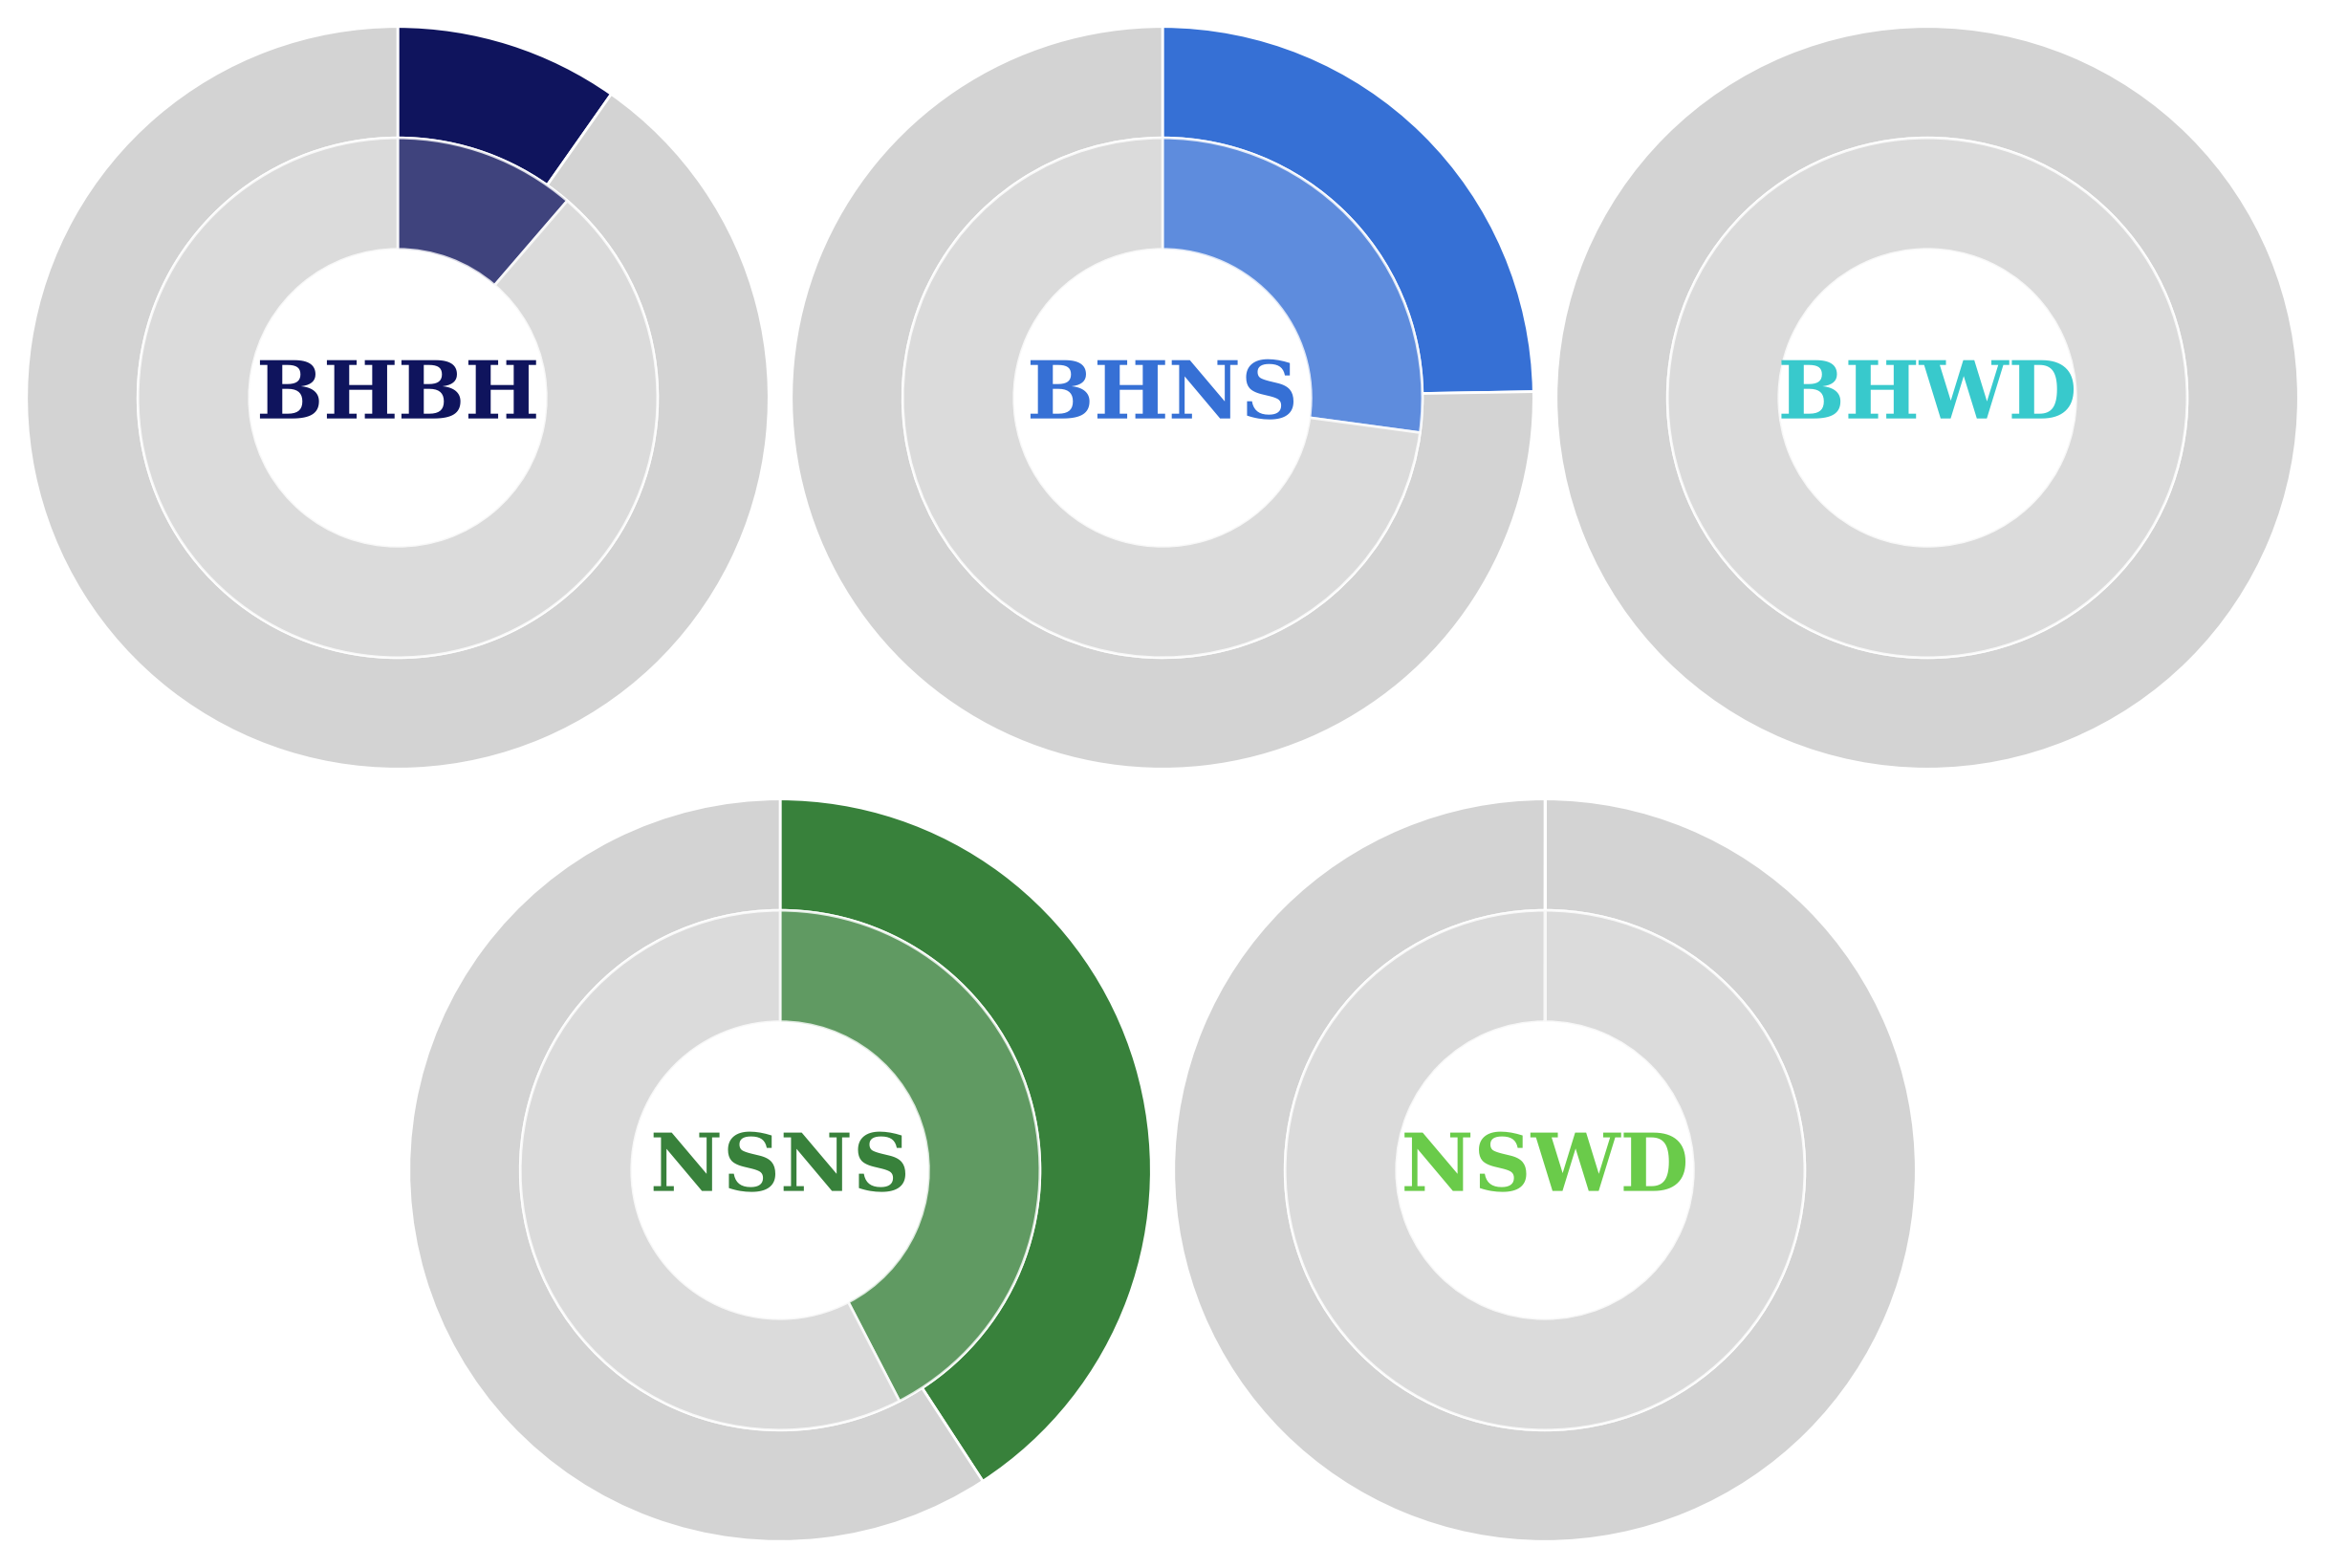

In [52]:
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 6, left=0, right=1, bottom=0, top=1, wspace=0, hspace=0.02)

# each panel spans two columns so the bottom row can be offset by one to centre it
positions = [gs[0, 0:2], gs[0, 2:4], gs[0, 4:6], gs[1, 1:3], gs[1, 3:5]]

for dco_type, pos in zip(const.DCO_TYPES, positions):
    at_least_two_harmonics = unc_data[dco_type]["detectable_harmonics"] >= 2
    ecc_detectable = lisa_sources[dco_type].ecc >= min_detectable_ecc(lisa_sources[dco_type].snr, lisa_sources[dco_type].f_orb * lisa_sources[dco_type].max_snr_harmonic)
    ecc_detectable_no_fmin = lisa_sources[dco_type].ecc >= min_detectable_ecc(lisa_sources[dco_type].snr, lisa_sources[dco_type].f_orb * lisa_sources[dco_type].max_snr_harmonic, f_min=0 * u.mHz)
    w = lisa_pops[dco_type].bpp["weights"]

    measureable_ecc = w[at_least_two_harmonics | ecc_detectable].sum() / w.sum()
    measureable_ecc_no_fmin = w[at_least_two_harmonics | ecc_detectable_no_fmin].sum() / w.sum()

    print(f"{dco_type}: {measureable_ecc:1.3f} of sources have measurable eccentricity")

    ax = fig.add_subplot(pos)

    # outer ring is with the frequency cut, inner ring is without
    for vals, rad, alpha in zip(
        [[measureable_ecc, 1 - measureable_ecc], [measureable_ecc_no_fmin, 1 - measureable_ecc_no_fmin]],
        [1, 0.7],
        [1, 0.8]
    ):
        ax.pie(
            vals,
            colors=[const.DCO_COLOURS[dco_type], "lightgrey"],
            startangle=90,
            counterclock=False,
            radius=rad,
            wedgeprops=dict(width=0.3, edgecolor='white', alpha=alpha)
        )
    ax.annotate(dco_type, xy=(0, 0), ha='center', va='center', fontsize=1.25*fs,
                fontweight='bold', color=const.DCO_COLOURS[dco_type])

    ax.set_xlim(-1.02, 1.02)
    ax.set_ylim(-1.02, 1.02)

plt.show()

BHBH first crosses WDWD at 5.80 kpc
BHNS first crosses WDWD at 5.60 kpc
BHWD never crosses WDWD
NSNS never crosses WDWD
NSWD first crosses WDWD at 4.40 kpc


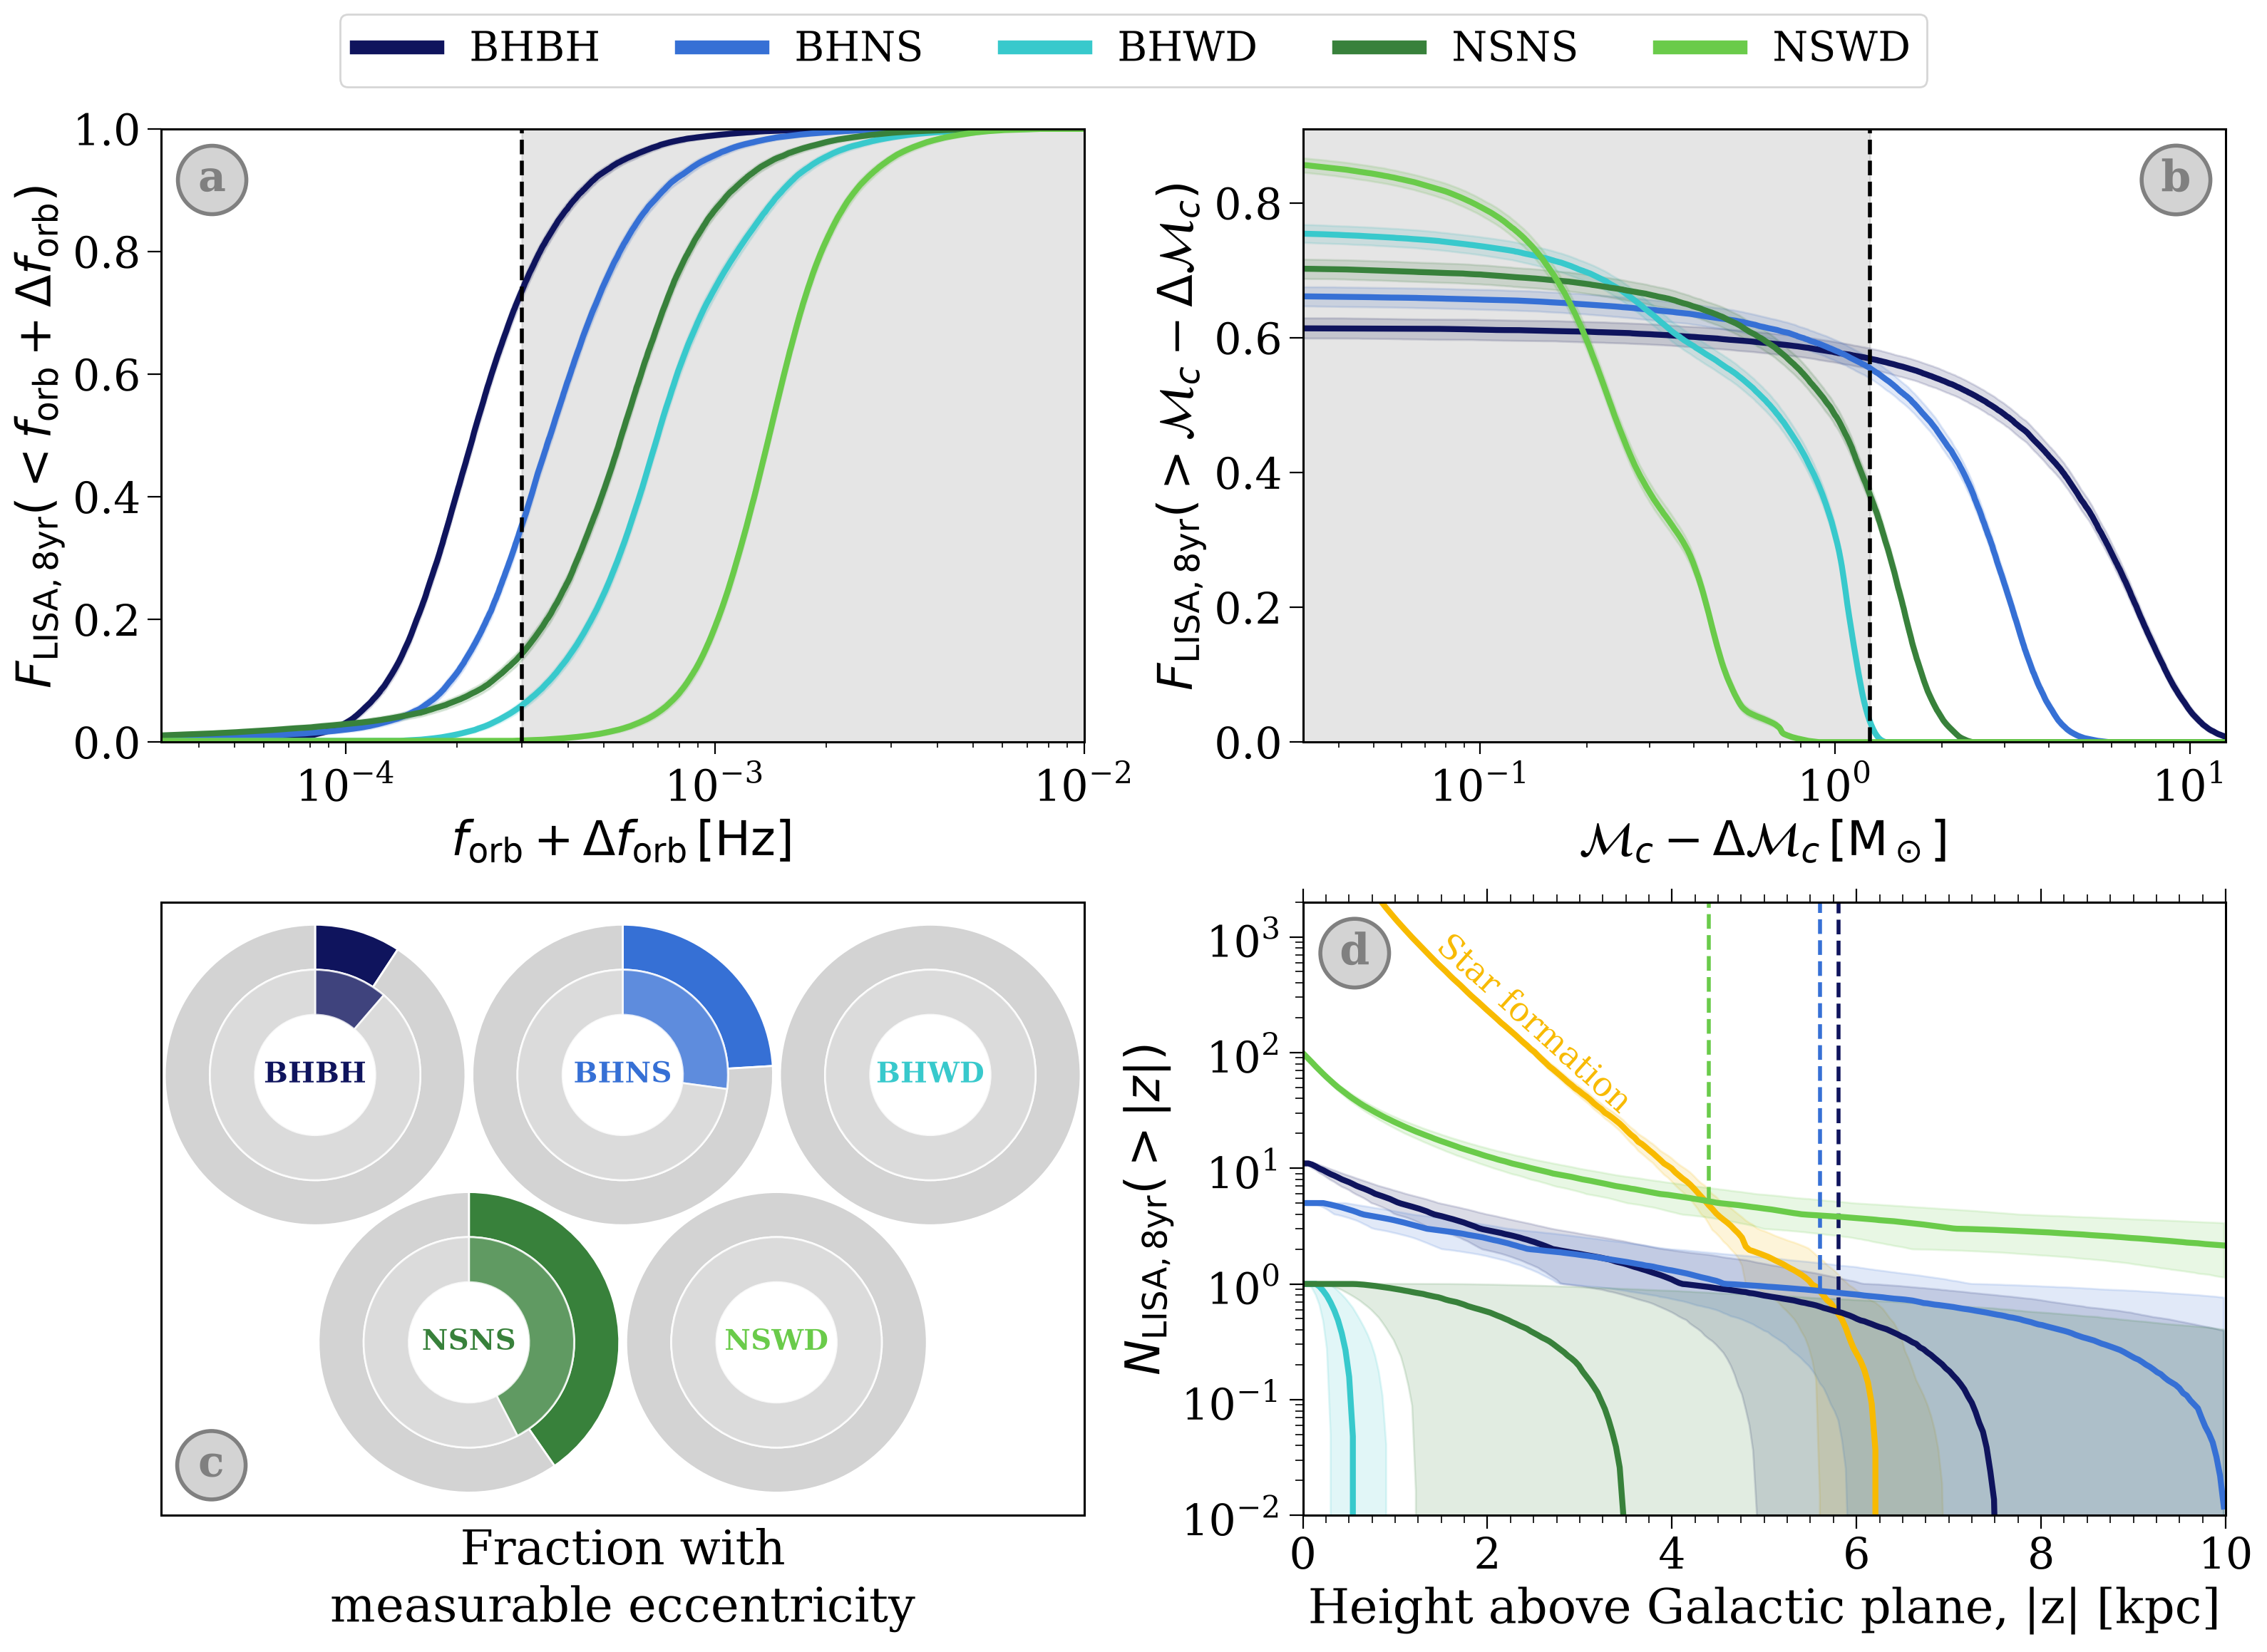

In [9]:
reload(plotting)
reload(unc)
counts = {"BHBH": 12, "BHNS": 6, "BHWD": 2, "NSNS": 2, "NSWD": 99}
fig, axes, height_where_exceeds_wdwds = plotting.four_panel_uncertainties(
    lisa_sources, lisa_pops, unc_data, wdwd_dist, detectable_pops, counts,
    n_boot=5000, save="../plots/dco_measured_properties.pdf", show=True
)

BHBH first crosses WDWD at 5.80 kpc
BHNS first crosses WDWD at 5.64 kpc
BHWD never crosses WDWD
NSNS never crosses WDWD
NSWD first crosses WDWD at 4.36 kpc


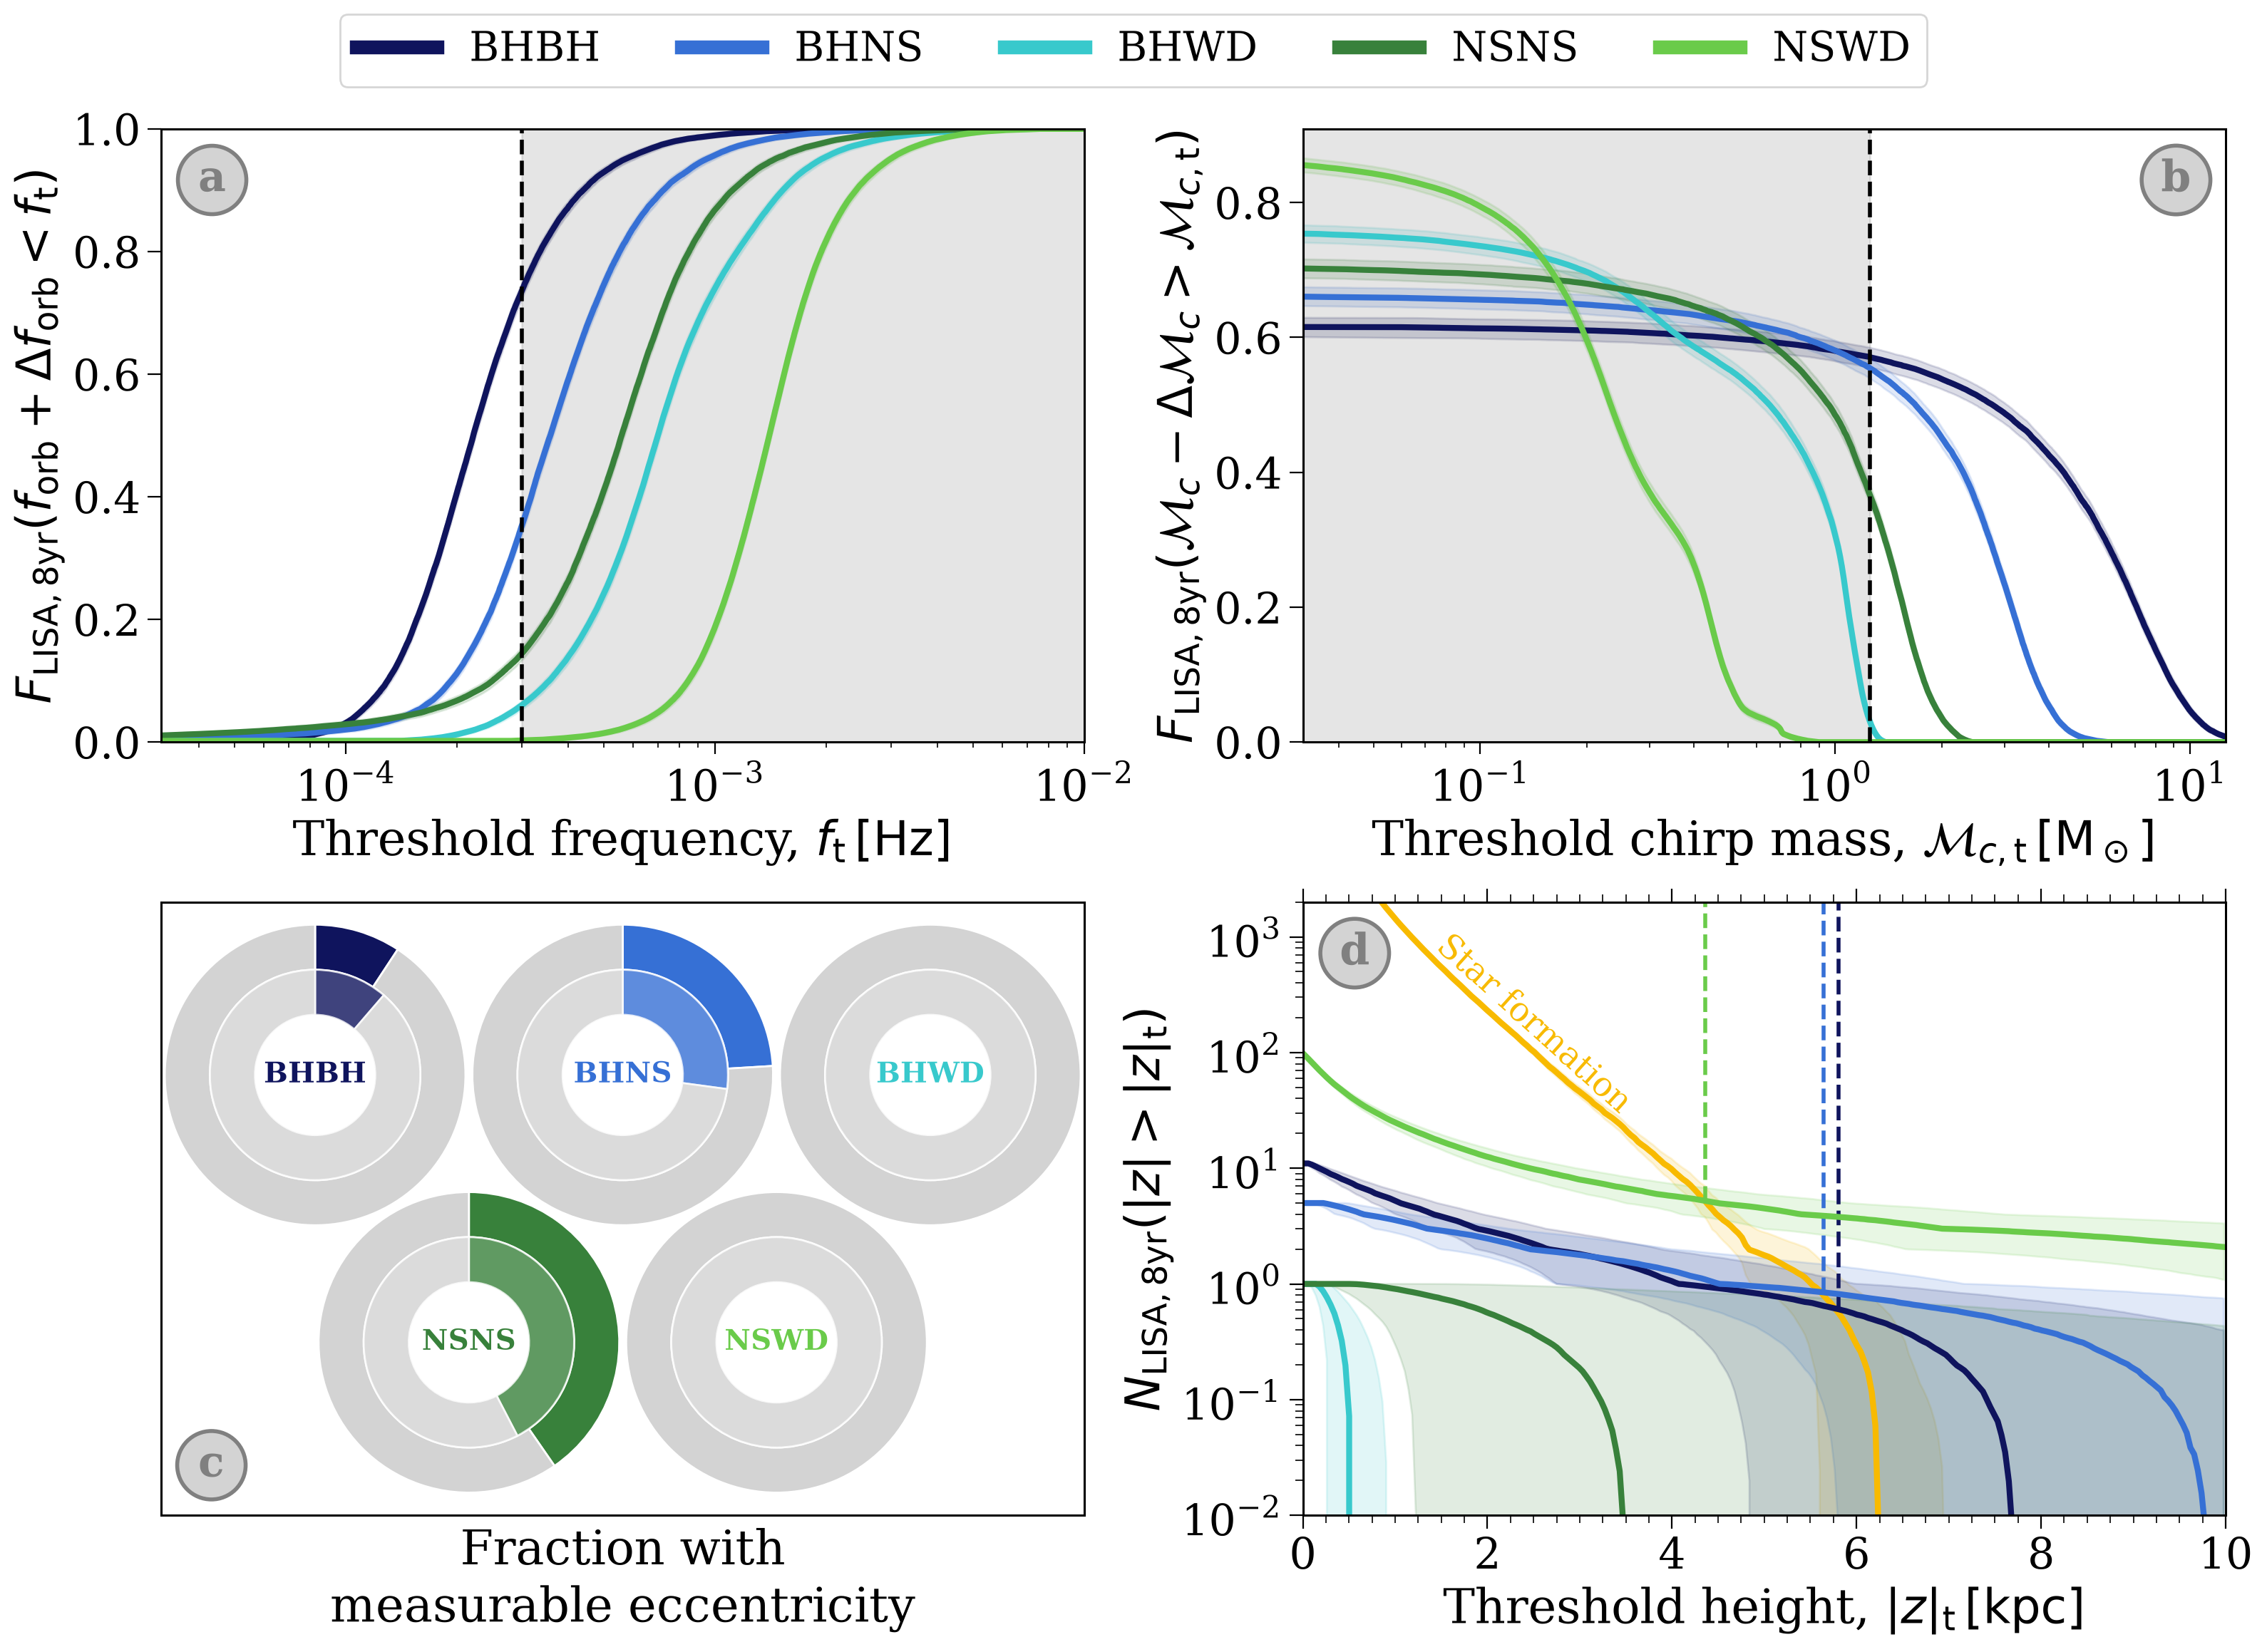

In [154]:
reload(plotting)
reload(unc)
counts = {"BHBH": 12, "BHNS": 6, "BHWD": 2, "NSNS": 2, "NSWD": 99}
fig, axes, height_where_exceeds_wdwds = plotting.four_panel_uncertainties(
    lisa_sources, lisa_pops, unc_data, wdwd_dist, detectable_pops, counts,
    n_boot=5000, save="../plots/dco_measured_properties.pdf", show=True
)

In [40]:
lisa_pops["BHBH"].bpp

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,bin_num,weights,remove_if_pessimistic,...,ecc_present_day,snr_lisa_8yr_initial_pos,snr_lisa_4yr_initial_pos,snr_lisa_8yr_final_pos,snr_lisa_4yr_final_pos,snr_decigo_8yr_initial_pos,snr_decigo_4yr_initial_pos,snr_decigo_8yr_final_pos,snr_decigo_4yr_final_pos,MW_instance
7242,6.577797,11.689343,8.769088,14,14,7.789378,0.218198,7242,0.037438,False,...,0.034265,2.839488,2.001869,13.797328,9.727266,0.0,0.0,0.0,0.0,0
11070,7.027529,16.389107,5.632334,14,14,9.115847,0.392681,11070,0.021068,False,...,0.024833,91.823069,62.967840,18.941068,12.988872,0.0,0.0,0.0,0.0,0
11339,6.236356,31.279947,10.949866,14,14,15.360486,0.024997,11339,0.041262,False,...,0.002027,7.891740,5.569016,17.984748,12.691414,0.0,0.0,0.0,0.0,0
17191,6.961870,22.583729,6.627213,14,14,16.267139,0.171164,17191,0.036423,False,...,0.005474,21.384063,14.900507,16.319833,11.371730,0.0,0.0,0.0,0.0,0
28108,7.899032,14.779052,4.516522,14,14,13.189022,0.171032,28108,0.034015,False,...,0.003575,98.583912,66.475267,101.946211,68.742470,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1241971110,10.274615,11.791740,4.676541,14,14,20.893068,0.493534,1241971110,0.107771,False,...,0.010046,28.588932,19.757833,42.177569,29.148951,0.0,0.0,0.0,0.0,2579
1241999556,7.502187,15.487792,4.943503,14,14,21.312170,0.392833,1241999556,0.024858,False,...,0.007636,22.534713,15.623475,21.687208,15.035895,0.0,0.0,0.0,0.0,2579
1242004386,7.903817,15.062709,3.648706,14,14,19.821141,0.411483,1242004386,0.032060,False,...,0.006652,32.944259,22.461722,91.267455,62.227054,0.0,0.0,0.0,0.0,2579
1242015697,6.148215,27.473076,6.973389,14,14,28.812175,0.325809,1242015697,0.034047,False,...,0.005971,22.934546,16.037026,49.577352,34.667060,0.0,0.0,0.0,0.0,2579


In [37]:
df1 = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/fiducial/uncertainties_pessimistic.h5", key="distinguishers")
df2 = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/fiducial/uncertainties.h5", key="distinguishers")

# combine df1 and df2 with a multiindex where the first level is "pessimistic" or "optimistic" and the second level is the dco_type
df1["model"] = "fiducial"
df2["model"] = "optimistic"
combo_df = pd.concat([df1, df2], axis=0)
combo_df = combo_df.set_index(["model"], append=True).reorder_levels([1, 0] + list(range(2, combo_df.index.nlevels + 1)))
combo_df

too_low_freq  too_massive  measureable_eccentricity  \
model                                                                  
fiducial   BHBH         0.695        0.571                     0.093   
           BHNS         0.370        0.548                     0.240   
           BHWD         0.058        0.032                     0.000   
           NSNS         0.148        0.377                     0.404   
           NSWD         0.002        0.000                     0.000   
optimistic BHBH         0.729        0.504                     0.127   
           BHNS         0.374        0.504                     0.354   
           BHWD         0.033        0.149                     0.000   
           NSNS         0.142        0.136                     0.658   
           NSWD         0.003        0.000                     0.014   

                 too_far_from_plane  m_forb  m_forb_ecc  m_forb_ecc_z  
model                                                                  
fiducial   BHBH               0.026   0.988       0.989         0.989  
           BHNS               0.089   0.883       0.894         0.896  
           BHWD               0.000   0.089       0.089         0.089  
           NSNS               0.000   0.524       0.630         0.630  
           NSWD               0.019   0.002       0.003         0.022  
optimistic BHBH               0.015   0.989       0.990         0.990  
           BHNS               0.055   0.845       0.889         0.891  
           BHWD               0.000   0.182       0.182         0.182  
           NSNS               0.000   0.277       0.723         0.723  
           NSWD               0.014   0.003       0.017         0.031

In [69]:
wdwd_dist.positions.shape

(3, 500000)

In [155]:
# calculate distance from (8, 0, 0)
dist = np.linalg.norm(wdwd_dist.positions.T - np.array([8, 0, 0]) * u.kpc, axis=1)
(dist < 350 * u.pc).sum() / 500_000 * 25000

np.float64(7.3)

In [ ]:
df1

,too_low_freq,too_massive,measureable_eccentricity,too_far_from_plane,m_forb,m_forb_ecc,m_forb_ecc_z
BHBH,0.695,0.571,0.093,0.026,0.988,0.989,0.989
BHNS,0.370,0.548,0.240,0.089,0.883,0.894,0.896
BHWD,0.058,0.032,0.000,0.000,0.089,0.089,0.089
NSNS,0.148,0.377,0.404,0.000,0.524,0.630,0.630
NSWD,0.002,0.000,0.000,0.019,0.002,0.003,0.022


In [41]:
import matplotlib as mpl

In [65]:
detectable_sources["BHBH"].get_snr()

array([ 8.49696946, 11.06121015,  6.06673453, ..., 11.86861495,
        3.52626547,  6.15737892], shape=(108838,))

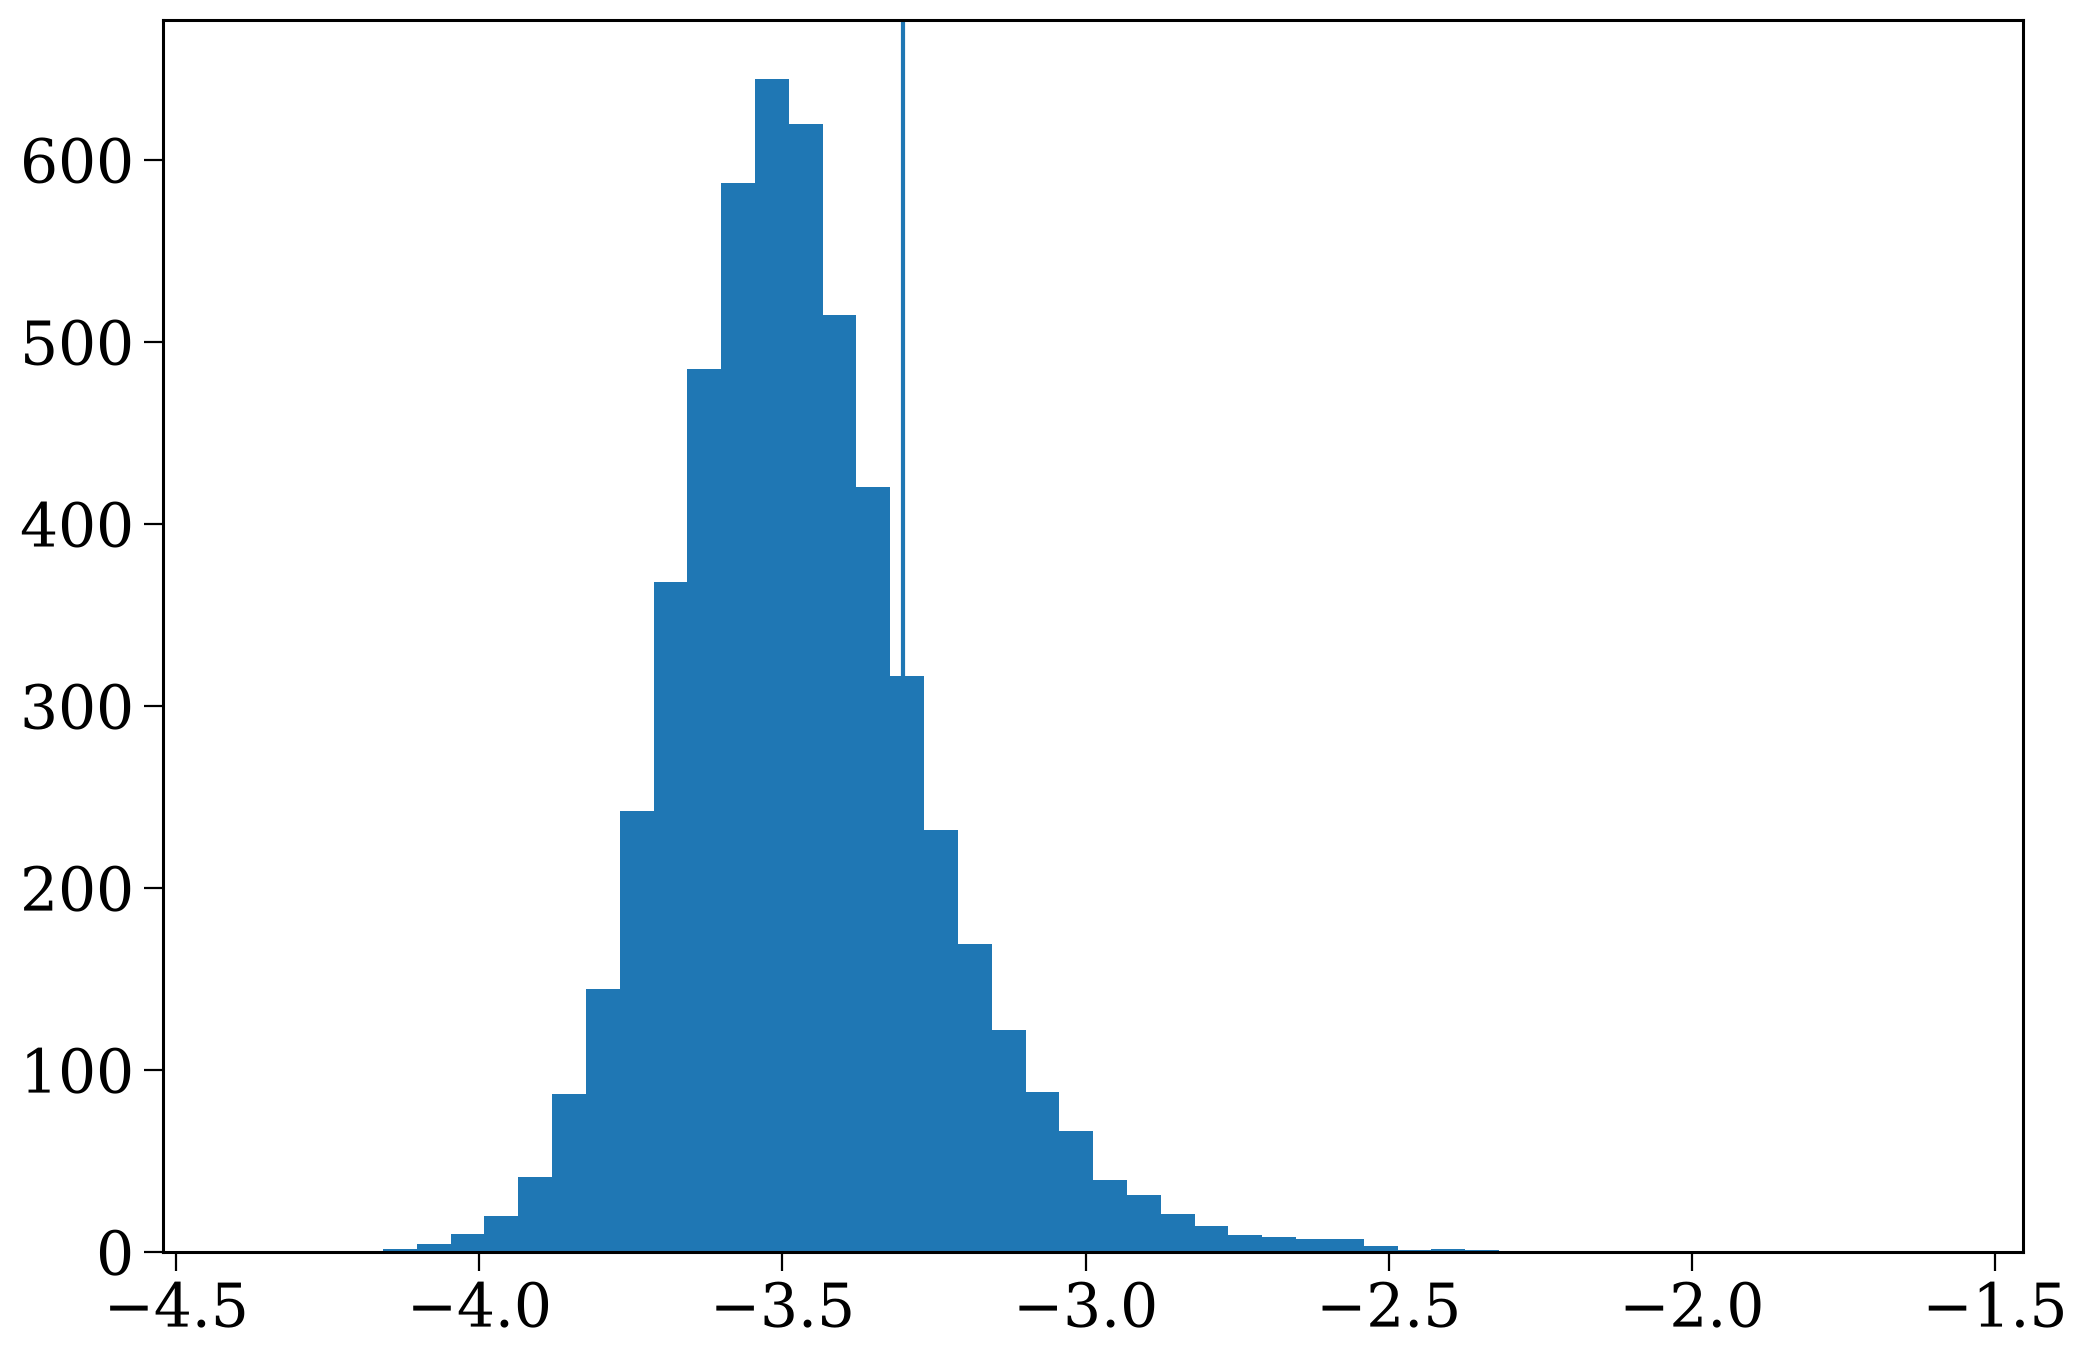

In [72]:
plt.hist(np.log10(detectable_sources["BHBH"].f_orb.value * detectable_sources["BHBH"].max_snr_harmonic), weights=detectable_pops["BHBH"].initC["weights"], bins=50);
plt.axvline(np.log10(0.5e-3))

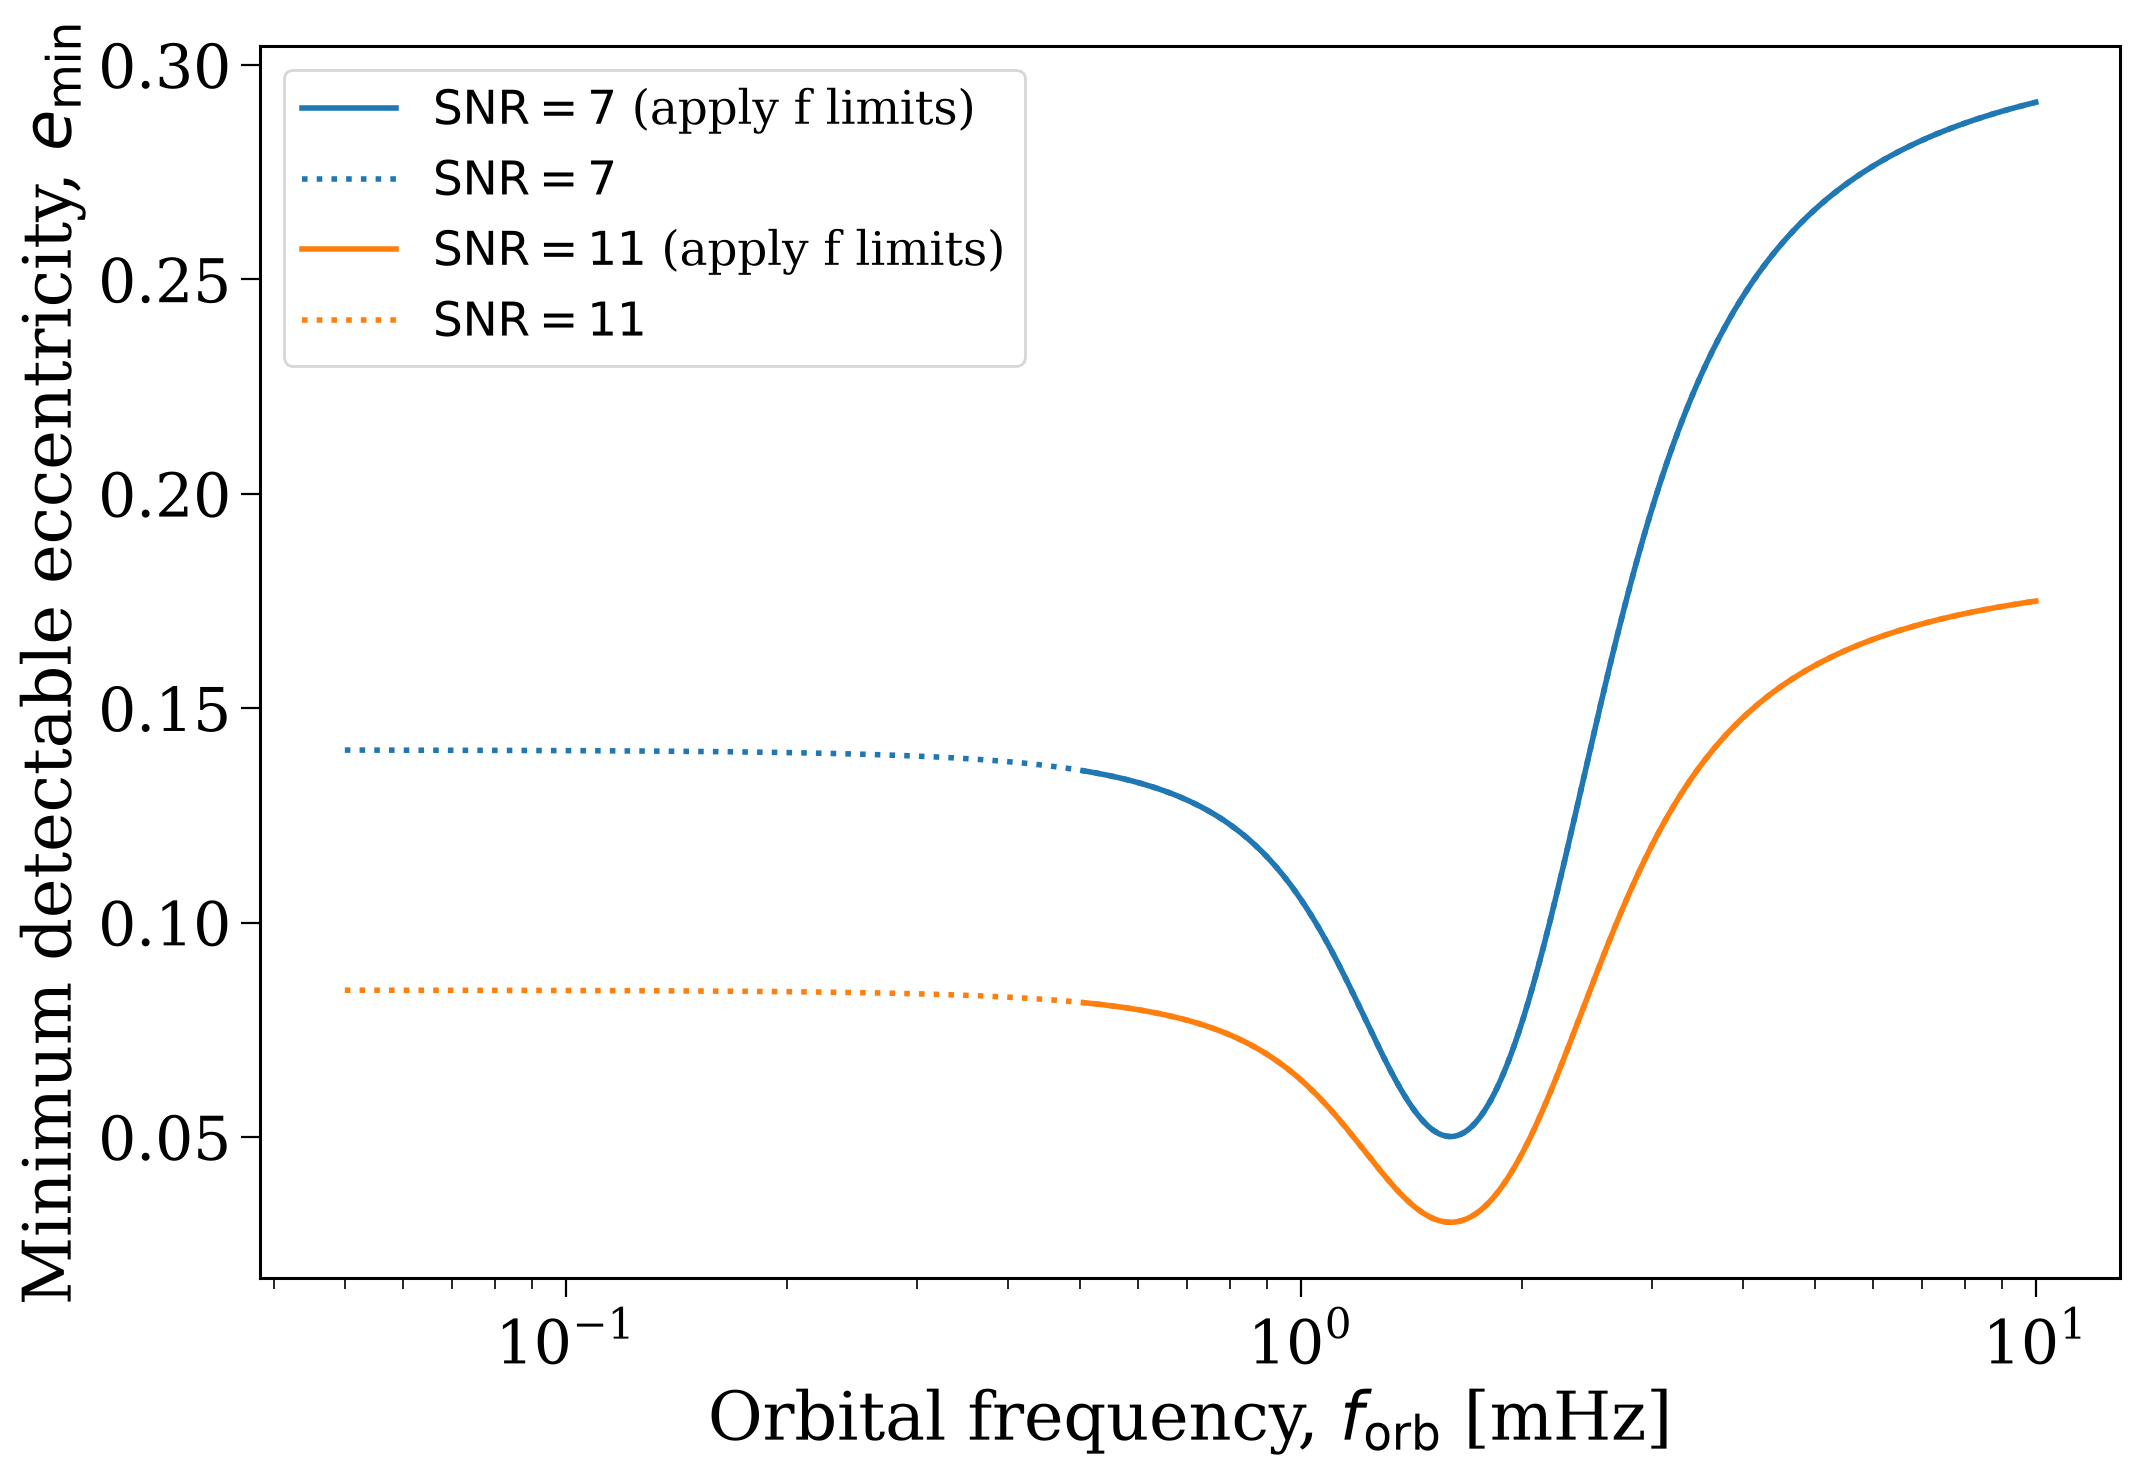

In [86]:
snr_range = np.linspace(7, 100, 100)
f_range = np.linspace(0.05, 10, 1001) * u.mHz

SNR, F = np.meshgrid(snr_range, f_range)

# fig, ax = plt.subplots()

# contourf = ax.contourf(np.log10(SNR), np.log10(F.to(u.mHz).value), np.log10(min_detectable_ecc(SNR, F, f_min=0)), levels=np.linspace(-3, 0, 21), cmap="plasma")
# fig.colorbar(contourf)
# plotting.fake_log_axis(ax, axis="y")
# plotting.fake_log_axis(ax, axis="x")

# plt.show()

for i, snr in enumerate([7, 11]):
    plt.plot(f_range.to(u.mHz).value[f_range > 0.5 * u.mHz], min_detectable_ecc(snr, f_range)[f_range > 0.5 * u.mHz], lw=2, label=rf"$\rm SNR = {snr}$ (apply f limits)", linestyle="-", color=f'C{i}')
    plt.plot(f_range.to(u.mHz).value, min_detectable_ecc(snr, f_range, f_min=0), lw=2, label=rf"$\rm SNR = {snr}$", color=f'C{i}', linestyle=":")
plt.xscale("log")
plt.ylabel(r"Minimum detectable eccentricity, $e_{\rm min}$")
plt.xlabel(r"Orbital frequency, $f_{\rm orb}$ [mHz]")
plt.legend()

<function nan_to_num at 0x14cde4009cf0>

In [123]:
pd.set_option('display.max_columns', None)

In [128]:
lisa_pops[dco_type].bpp

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,ecc,bin_num,weights,remove_if_pessimistic,rlof_time,rlof_sep,evol_type,sep_present_day,ecc_present_day,snr_lisa_8yr_initial_pos,snr_lisa_4yr_initial_pos,snr_lisa_8yr_final_pos,snr_lisa_4yr_final_pos,snr_decigo_8yr_initial_pos,snr_decigo_4yr_initial_pos,snr_decigo_8yr_final_pos,snr_decigo_4yr_final_pos,MW_instance
9692,168.767639,3.374270,0.531034,14,11,2.406261,0.0,9692,0.044961,False,8631.617750,0.058353,15,0.269578,0.0,111.952975,74.791588,213.306597,142.502146,219.851475,128.484877,418.888111,244.805214,0
14757,275.937788,3.809458,0.531034,14,11,2.230364,0.0,14757,0.030285,False,1322.619635,0.060389,15,0.578828,0.0,4.451217,2.906100,15.302402,9.990595,0.000000,0.000000,0.000000,0.000000,0
16984,217.425517,3.033256,0.531034,14,11,1.775232,0.0,16984,0.047996,False,1662.164656,0.056634,15,0.577777,0.0,2.682136,1.778992,18.490683,12.264394,0.000000,0.000000,0.000000,0.000000,0
18184,163.266171,4.197042,0.531034,14,11,3.040856,0.0,18184,0.032028,False,NaN,NaN,15,1.072825,0.0,0.526906,0.368834,12.345824,8.642074,0.000000,0.000000,0.000000,0.000000,0
39020,153.606123,4.371291,0.531034,14,11,3.615102,0.0,39020,0.019174,False,NaN,NaN,15,0.529034,0.0,16.966156,10.565087,39.461321,24.573172,18.489193,11.278505,43.003729,26.232501,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1726091690,918.693814,4.220370,0.057479,14,11,0.269939,0.0,1726091690,0.044203,False,781.677702,0.061646,10,0.269939,0.0,14.764212,10.079675,19.418116,13.256941,30.391586,18.788532,39.971474,24.710962,2569
1726102350,741.224538,3.800173,0.062185,14,11,0.247666,0.0,1726102350,0.065585,False,672.746026,0.059797,10,0.247666,0.0,25.820113,18.023047,24.241838,16.921373,57.719732,38.379263,54.191565,36.033299,2569
1726107877,912.381522,3.644834,0.531034,14,11,0.228404,0.0,1726107877,0.020137,False,762.207509,0.059637,10,0.228404,0.0,249.584302,176.305465,241.586556,170.655885,671.924934,471.695588,650.393591,456.580448,2569
1726137077,2544.533482,3.950675,0.531034,14,11,0.478576,0.0,1726137077,0.051614,False,1564.228848,0.061018,10,0.478576,0.0,10.076947,6.047987,81.627544,48.991261,11.023862,6.441507,89.297958,52.178937,2569


In [126]:
np.nan_to_num(lisa_pops[dco_type].bpp["rlof_time"].values, 1e20)

array([8631.61775039, 1322.61963472, 1662.16465615, ...,  762.207509  ,
       1564.22884809, 9334.05179886], shape=(104448,))

In [ ]:
for dco_type in ["NSWD", "BHWD"]:
    w = lisa_pops[dco_type].bpp["weights"]
    
    print(w[].sum() / w.sum())


0.6360670444657255
0.2067317566580438


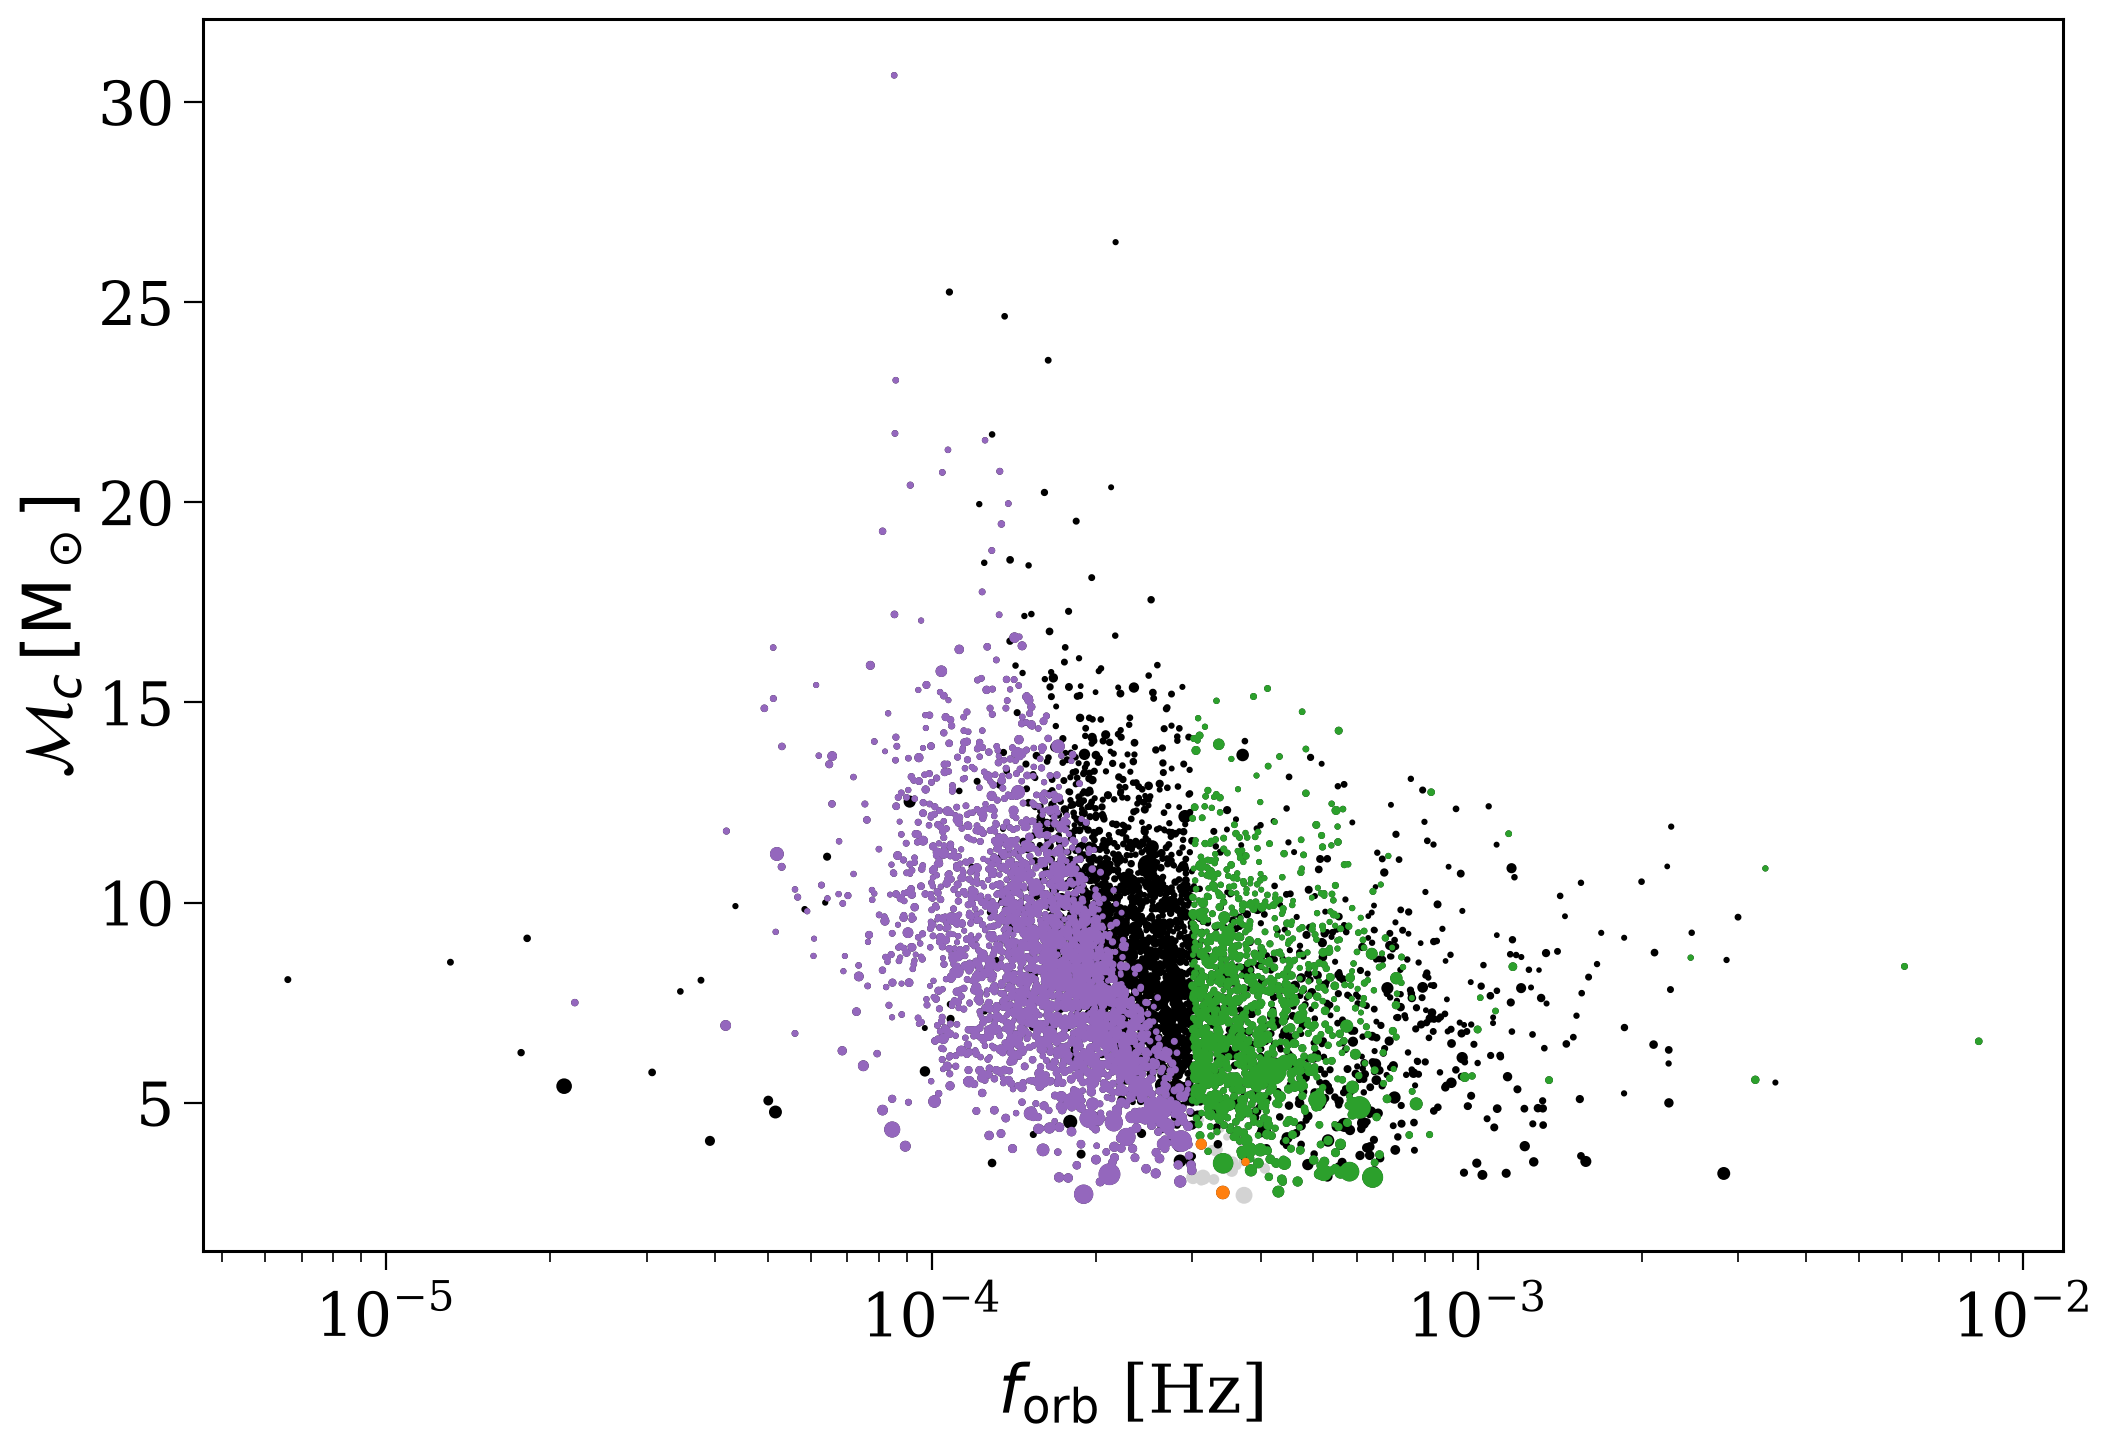

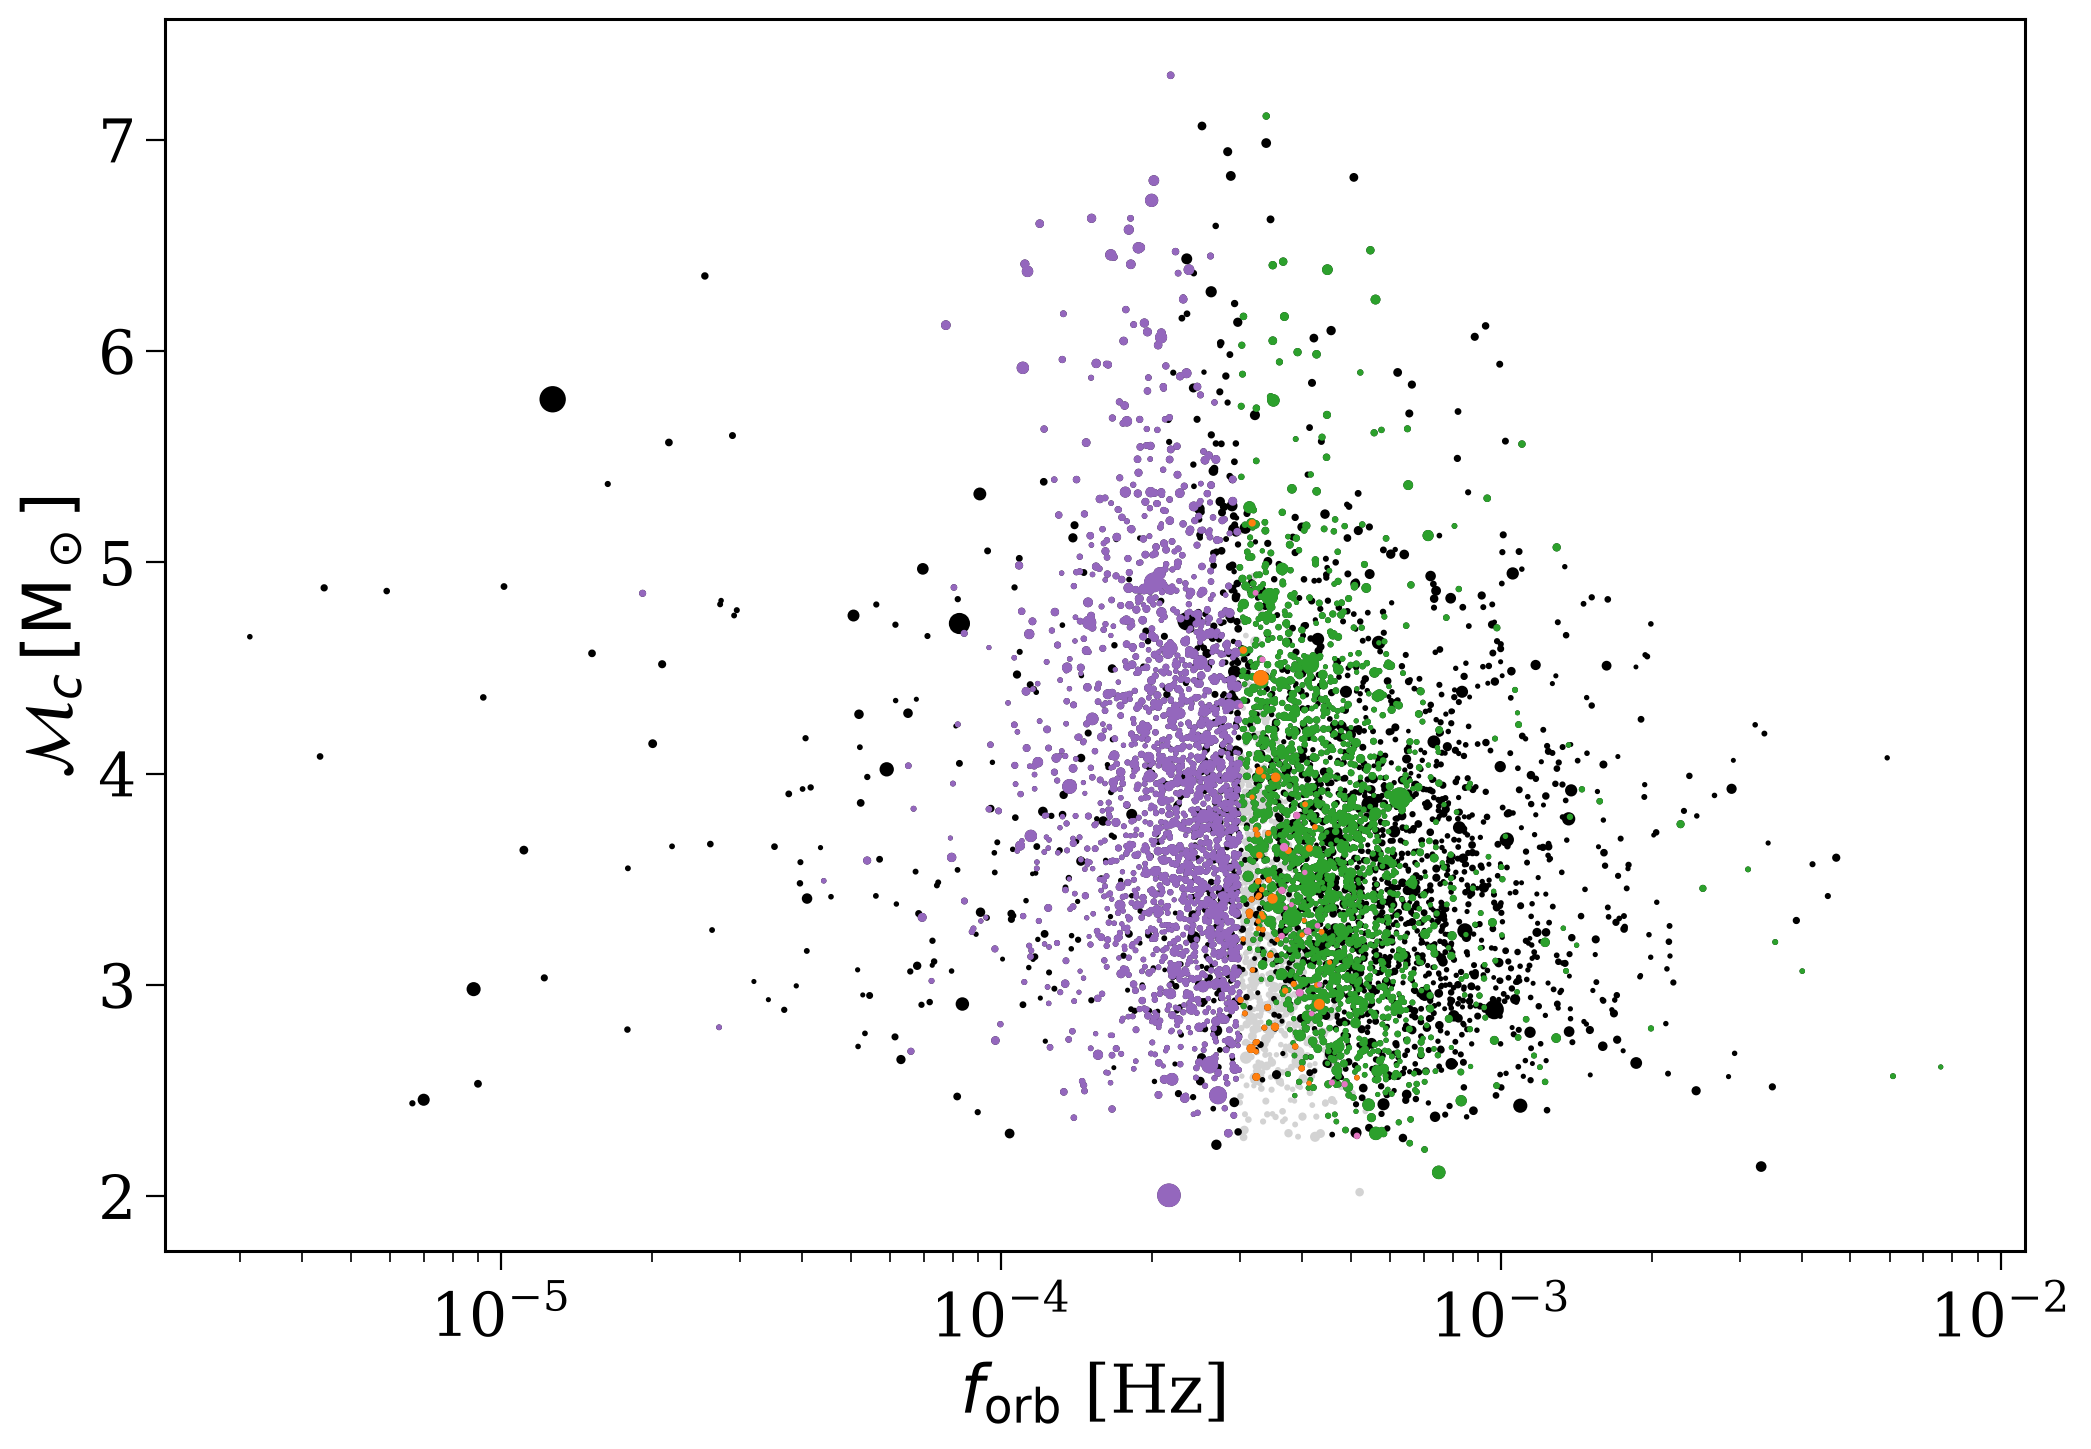

BHWD
BHWD: 0.207 of sources have reached RLOF
BHWD: 0.089 of sources are distinguishable by at least one property
BHWD: 0.005 of sources have reached RLOF and are distinguishable by at least one property


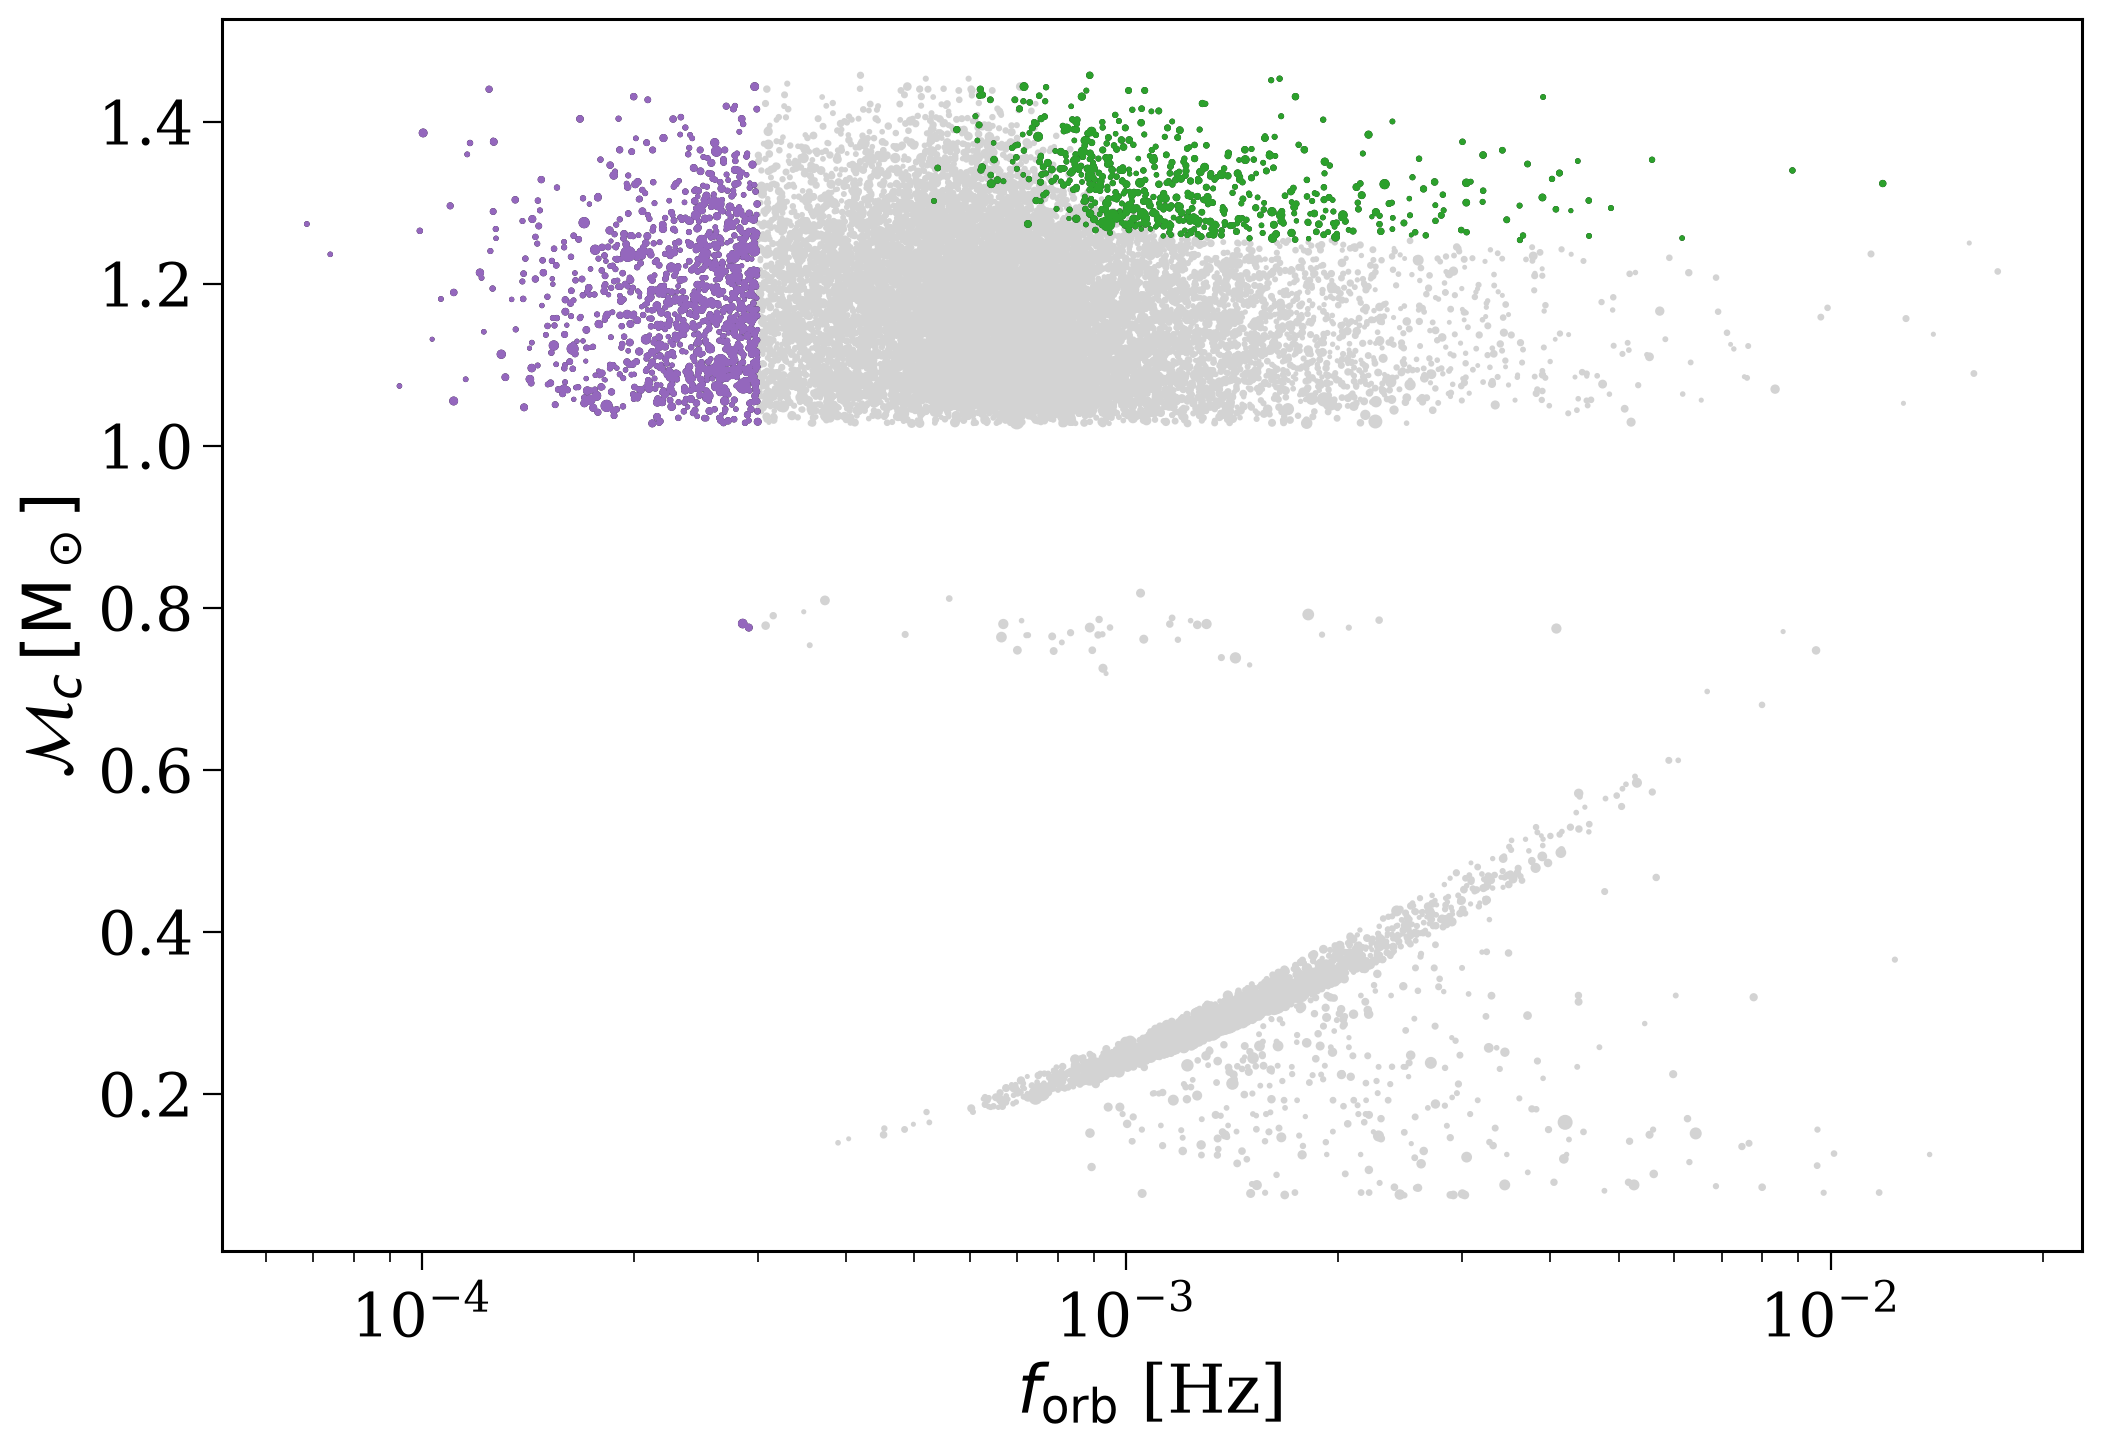

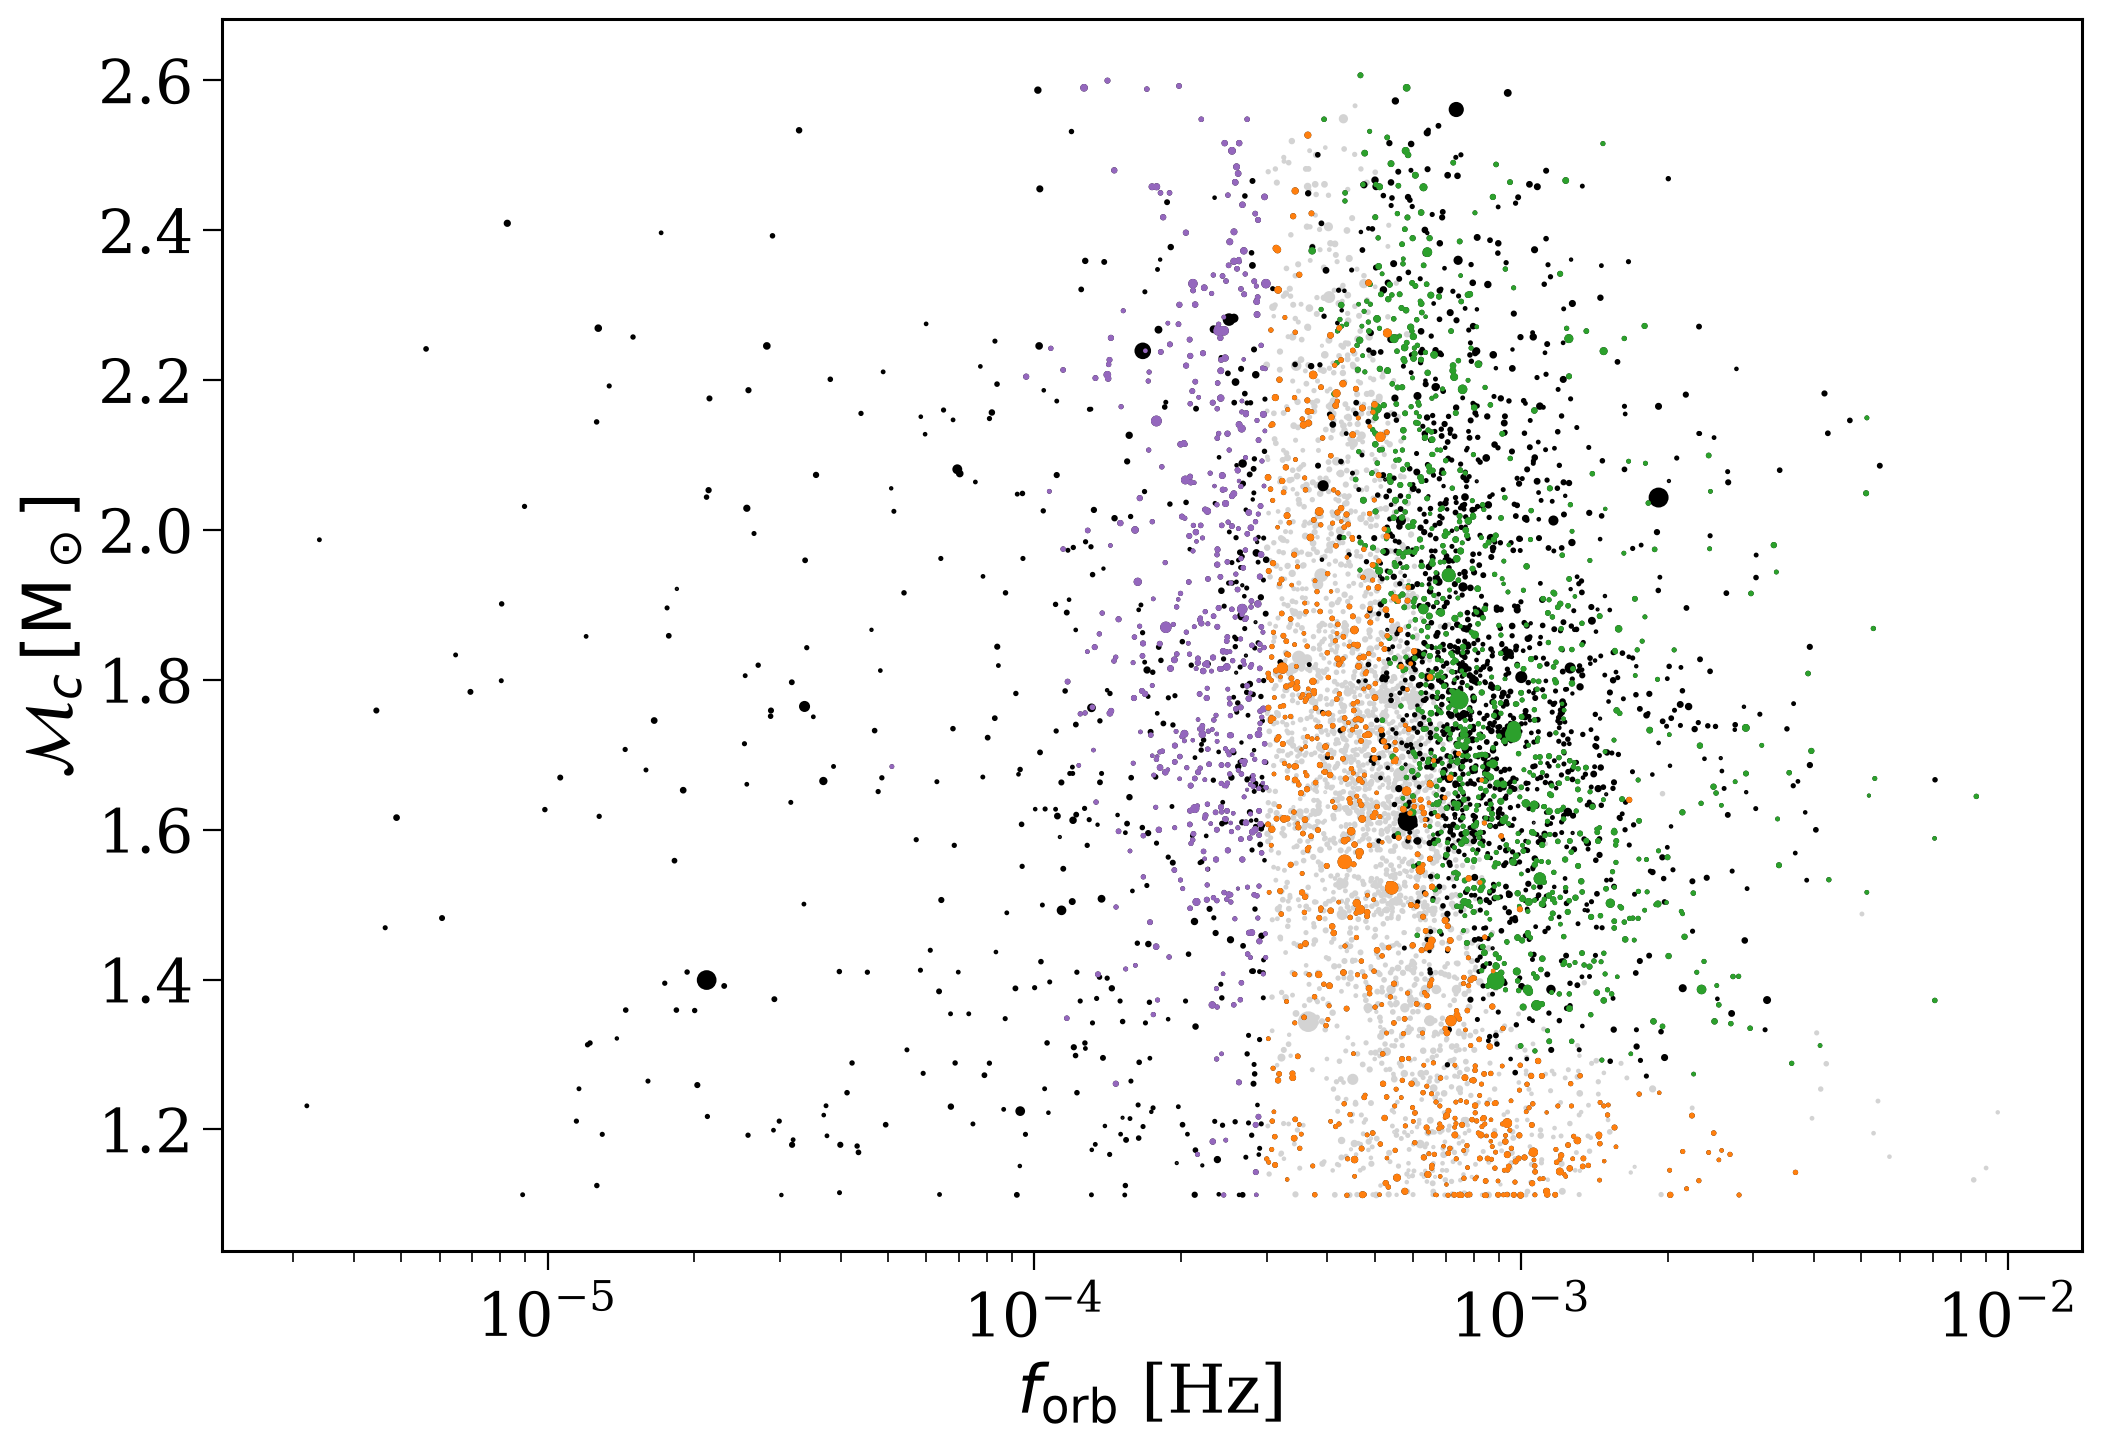

NSWD
NSWD: 0.636 of sources have reached RLOF
NSWD: 0.021 of sources are distinguishable by at least one property
NSWD: 0.011 of sources have reached RLOF and are distinguishable by at least one property


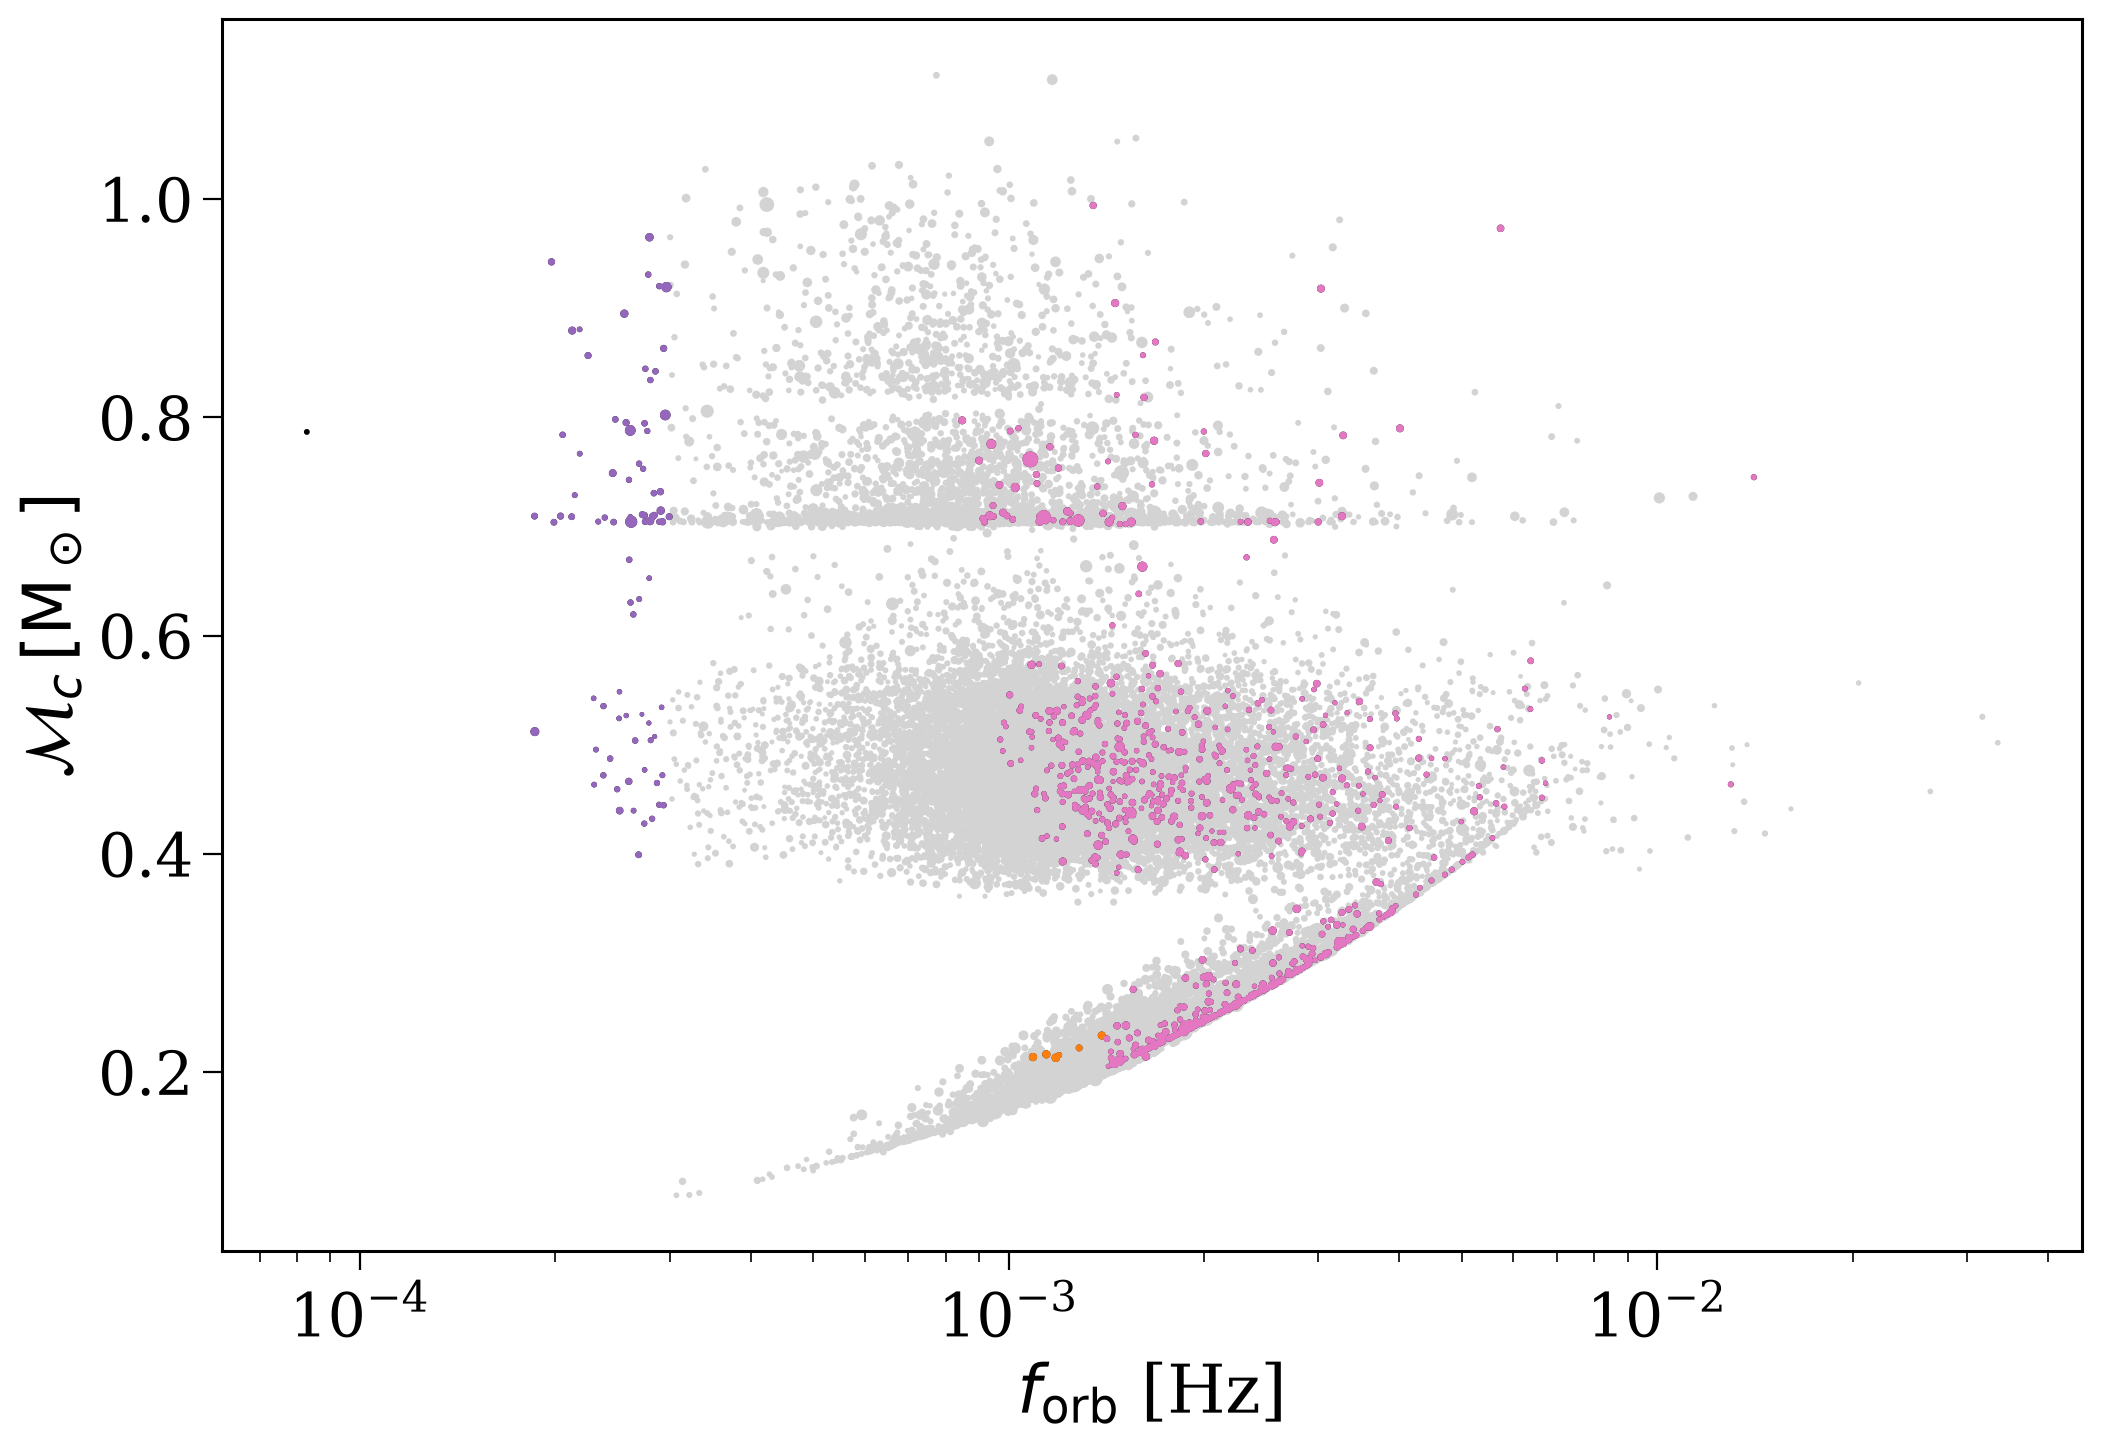

In [142]:


every = 5

height_where_exceeds_wdwds = {
    "BHBH": 5.5,
    "BHNS": 5.5,
    "BHWD": 10000,
    "NSNS": 10000,
    "NSWD": 4.5
}

for dco_type in const.DCO_TYPES:

    fig, ax = plt.subplots()

    too_massive = (lisa_sources[dco_type].m_c - unc_data[dco_type]["delta_m_c_over_m_c"] * lisa_sources[dco_type].m_c) > lw.utils.chirp_mass(1.44, 1.44) * u.Msun
    too_low_freq = (lisa_sources[dco_type].f_orb + unc_data[dco_type]["delta_forb"]) < 3e-4 * u.Hz
    at_least_two_harmonics = unc_data[dco_type]["detectable_harmonics"] >= 2
    ecc_detectable = lisa_sources[dco_type].ecc >= unc.min_detectable_ecc(lisa_sources[dco_type].snr, lisa_sources[dco_type].f_orb * lisa_sources[dco_type].max_snr_harmonic)
    measureable_eccentricity = at_least_two_harmonics | ecc_detectable
    too_far_from_plane = np.abs(lisa_pops[dco_type].final_pos[:, 2]) - unc_data[dco_type]["sigma_z"] > height_where_exceeds_wdwds[dco_type] * u.kpc

    if "WD" in dco_type:
        print(dco_type)
        w = lisa_pops[dco_type].bpp["weights"]
        reached_rlof = np.nan_to_num(lisa_pops[dco_type].bpp["rlof_time"].values, nan=15000) * u.Myr < lisa_pops[dco_type].initial_galaxy.tau
        dist_any = too_massive | too_low_freq | measureable_eccentricity | too_far_from_plane
        print(f"{dco_type}: {w[reached_rlof].sum() / w.sum():1.3f} of sources have reached RLOF")
        print(f"{dco_type}: {w[dist_any].sum() / w.sum():1.3f} of sources are distinguishable by at least one property")
        print(f"{dco_type}: {w[reached_rlof & dist_any].sum() / w.sum():1.3f} of sources have reached RLOF and are distinguishable by at least one property")

    too_massive = too_massive[::every]
    too_low_freq = too_low_freq[::every]
    measureable_eccentricity = measureable_eccentricity[::every]
    too_far_from_plane = too_far_from_plane[::every]
    dist_any = too_massive | too_low_freq | measureable_eccentricity | too_far_from_plane

    ax.scatter(lisa_sources[dco_type].f_orb.to(u.Hz).value[::every][~dist_any], lisa_sources[dco_type].m_c[::every][~dist_any], s=50 * lisa_pops[dco_type].bpp["weights"][::every][~dist_any],
            color="lightgrey")
    ax.scatter(lisa_sources[dco_type].f_orb.to(u.Hz).value[::every][dist_any], lisa_sources[dco_type].m_c[::every][dist_any], s=50 * lisa_pops[dco_type].bpp["weights"][::every][dist_any],
            color="k")

    ax.scatter(lisa_sources[dco_type].f_orb.to(u.Hz).value[::every][too_massive & ~too_low_freq & ~measureable_eccentricity & ~too_far_from_plane],
            lisa_sources[dco_type].m_c[::every][too_massive & ~too_low_freq & ~measureable_eccentricity & ~too_far_from_plane],
            s=52 * lisa_pops[dco_type].bpp["weights"][::every][too_massive & ~too_low_freq & ~measureable_eccentricity & ~too_far_from_plane],
            color="tab:green")

    ax.scatter(lisa_sources[dco_type].f_orb.to(u.Hz).value[::every][too_low_freq & ~too_massive & ~measureable_eccentricity & ~too_far_from_plane],
            lisa_sources[dco_type].m_c[::every][too_low_freq & ~too_massive & ~measureable_eccentricity & ~too_far_from_plane],
            s=52 * lisa_pops[dco_type].bpp["weights"][::every][too_low_freq & ~too_massive & ~measureable_eccentricity & ~too_far_from_plane],
            color="tab:purple")

    ax.scatter(lisa_sources[dco_type].f_orb.to(u.Hz).value[::every][measureable_eccentricity & ~too_massive & ~too_low_freq & ~too_far_from_plane],
            lisa_sources[dco_type].m_c[::every][measureable_eccentricity & ~too_massive & ~too_low_freq & ~too_far_from_plane],
            s=52 * lisa_pops[dco_type].bpp["weights"][::every][measureable_eccentricity & ~too_massive & ~too_low_freq & ~too_far_from_plane],
            color="tab:orange")

    ax.scatter(lisa_sources[dco_type].f_orb.to(u.Hz).value[::every][too_far_from_plane & ~too_massive & ~too_low_freq & ~measureable_eccentricity],
            lisa_sources[dco_type].m_c[::every][too_far_from_plane & ~too_massive & ~too_low_freq & ~measureable_eccentricity],
            s=52 * lisa_pops[dco_type].bpp["weights"][::every][too_far_from_plane & ~too_massive & ~too_low_freq & ~measureable_eccentricity],
            color="tab:pink")


    ax.set(
        xscale="log",
        # yscale="log",
        xlabel=r"$f_{\rm orb}$ [Hz]",
        ylabel=r"$\mathcal{M}_c \, [{\rm M_\odot}]$"
    )
    plt.show()

In [148]:
lw.source.Source(
    m_1=10 * u.Msun,
    m_2=10 * u.Msun,
    f_orb=3e-4 * u.Hz,
    ecc=0.0,
    dist=12 * u.pc,
    interpolate_g=False
).get_snr()

array([38962.01996384])

In [146]:
unc.get_wdwd_distinguishing_factors(
    lisa_sources, lisa_pops, unc_data, height_where_exceeds_wdwds, min_wdwd_forb=1.5e-4 * u.Hz
)

,too_low_freq,too_massive,measureable_eccentricity,too_far_from_plane,m_forb,m_forb_ecc,m_forb_ecc_z
BHBH,0.159,0.571,0.093,0.030,0.725,0.727,0.727
BHNS,0.056,0.548,0.240,0.092,0.604,0.637,0.639
BHWD,0.002,0.032,0.000,0.000,0.034,0.034,0.034
NSNS,0.045,0.377,0.404,0.000,0.422,0.567,0.567
NSWD,0.000,0.000,0.000,0.018,0.000,0.000,0.019
